# Ensemble Analysis: Feature Impact on Waiter-Level Fraud Detection

Analyses:
1. Feature correlation — redundancy between `share_anomaly_weeks_*` and `week_*` signals
2. Feature distributions: fraud vs normal
3. Ranking comparison: who moves in/out of top-10 when removing features
4. Undetected fraud waiters: what patterns does the model miss

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
sns.set_style("whitegrid")

risk = pd.read_csv("../waiter_ensemble_risk.csv")

ALL_FEATURES = [
    "iso_90", "ocsvm_90", "lof_90",
    "share_active_clients_only_this_waiter",
    "share_anomaly_weeks_iso", "share_anomaly_weeks_ocsvm", "share_anomaly_weeks_lof",
    "week_iso_max", "week_ocsvm_max", "week_lof_max",
    "week_iso_mean", "week_ocsvm_mean",
    "week_n_top5pct",
    "month_iso_max", "month_ocsvm_max", "month_lof_max",
    "month_iso_mean", "month_ocsvm_mean",
    "month_n_top5pct",
]

SHARE_COLS = ["share_anomaly_weeks_iso", "share_anomaly_weeks_ocsvm", "share_anomaly_weeks_lof"]

n_fraud = int(risk["is_fraud"].sum())
print(f"Waiters: {len(risk)}, Fraud: {n_fraud}")

Waiters: 4235, Fraud: 14


## 1. Feature Correlation Heatmap

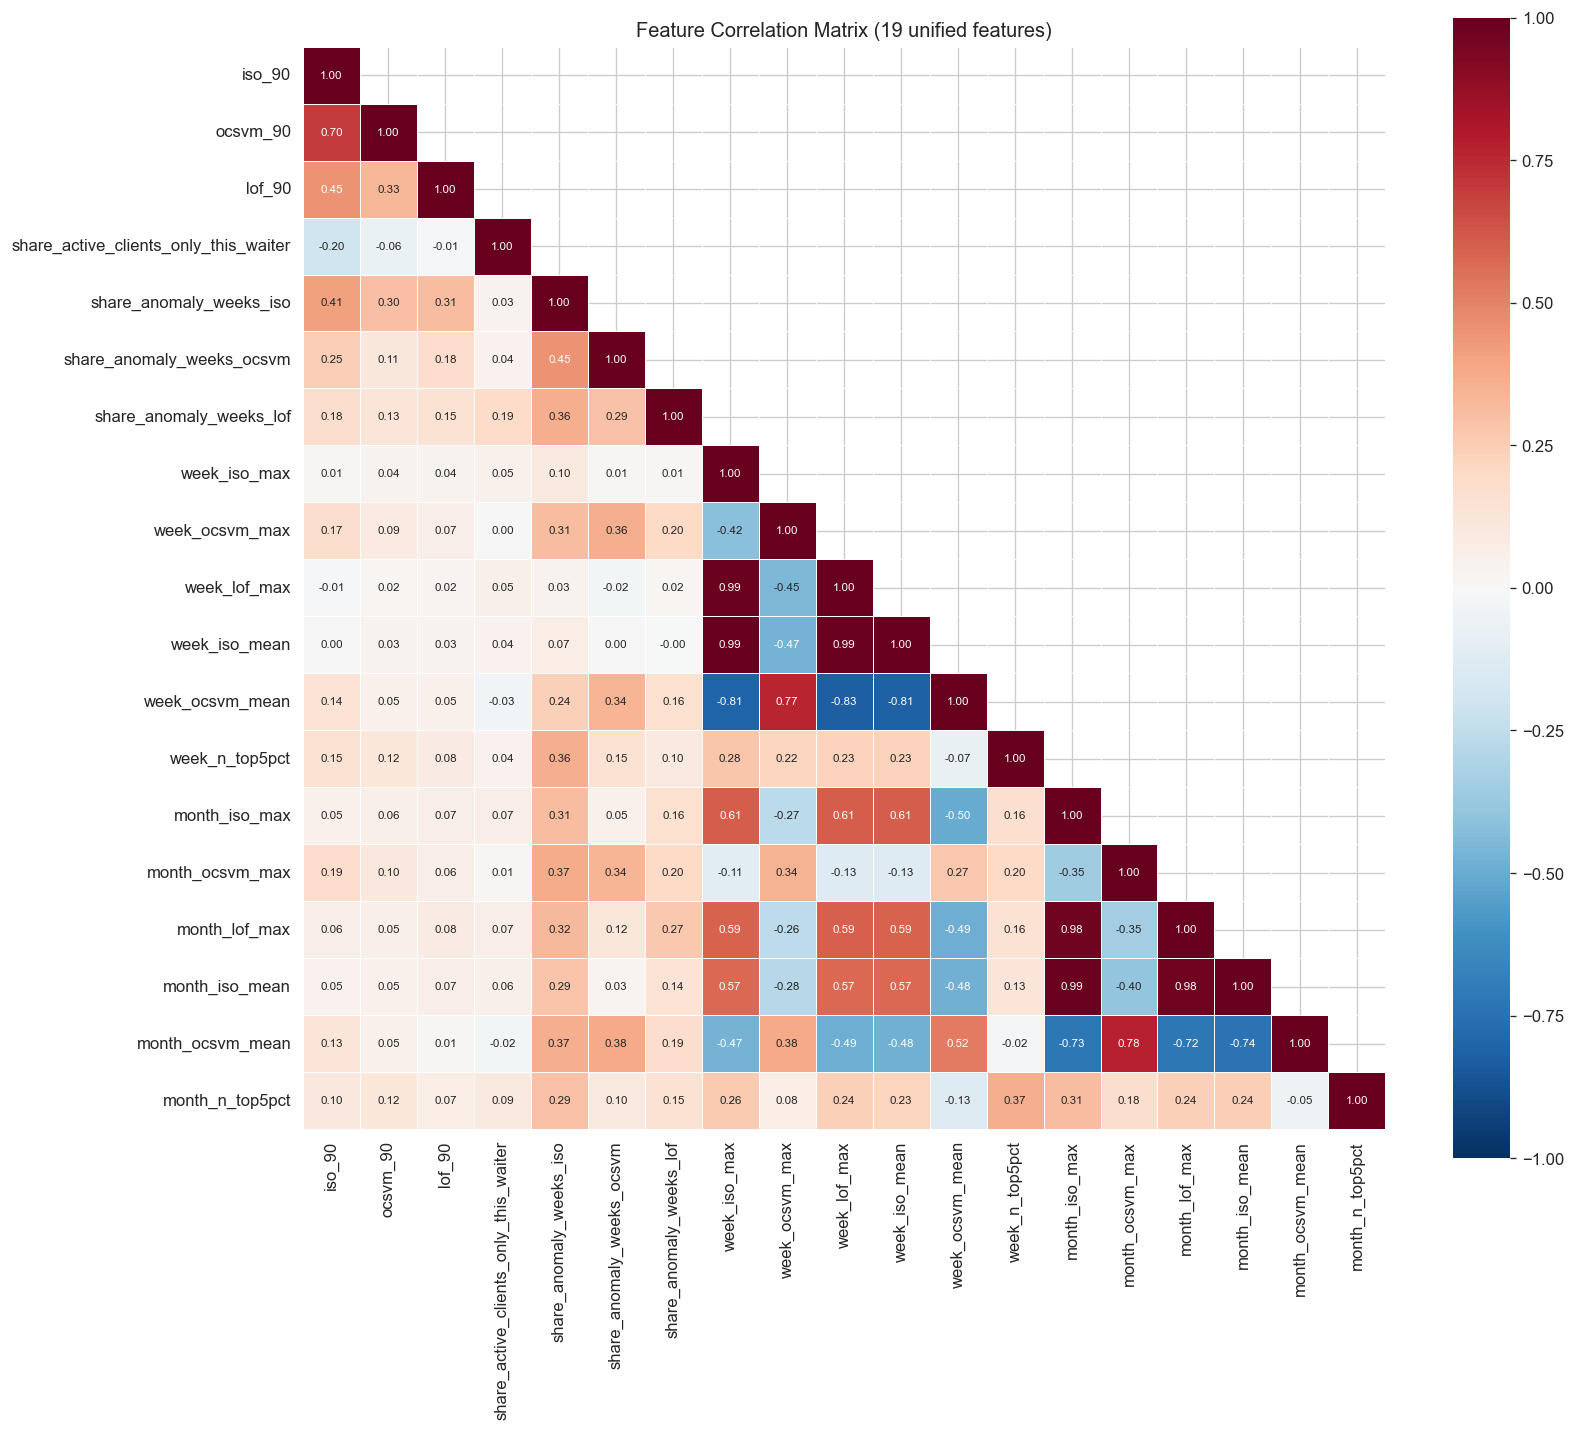

In [27]:
corr = risk[ALL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix (19 unified features)")
plt.tight_layout()
plt.show()

## 2. Redundancy: share_anomaly_weeks vs week_* signals

`share_anomaly_weeks_*` are precomputed from `waiter_week_anomaly_scores.csv` (threshold at 95th percentile, then share of flagged weeks). The `week_*_max/mean` are computed fresh in the pipeline. If they're highly correlated, `share_anomaly_weeks_*` is redundant noise.

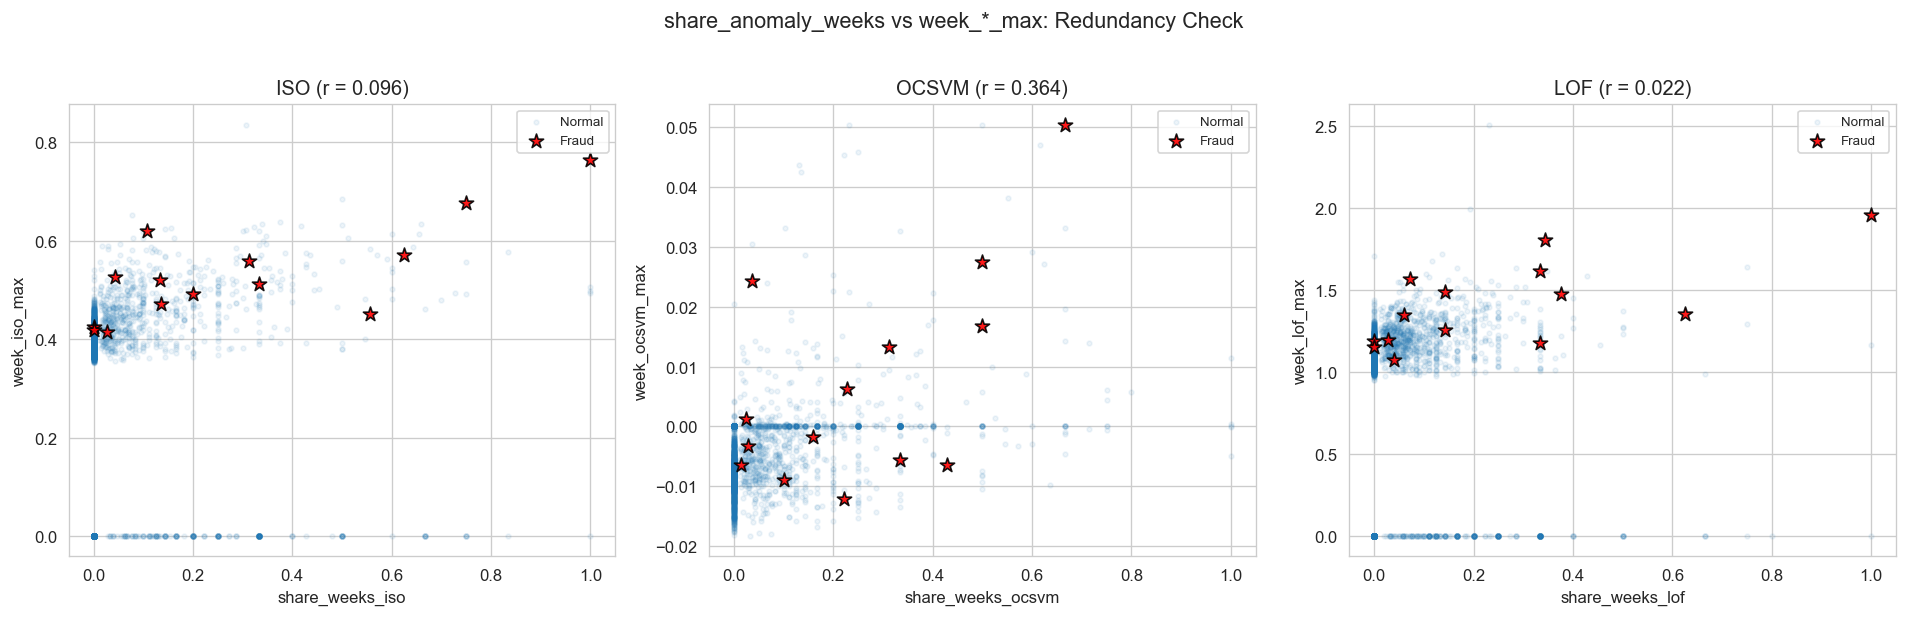

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [
    ("share_anomaly_weeks_iso", "week_iso_max", "ISO"),
    ("share_anomaly_weeks_ocsvm", "week_ocsvm_max", "OCSVM"),
    ("share_anomaly_weeks_lof", "week_lof_max", "LOF"),
]

for ax, (share_col, week_col, model) in zip(axes, pairs):
    fraud = risk[risk["is_fraud"] == 1]
    normal = risk[risk["is_fraud"] == 0]
    ax.scatter(normal[share_col], normal[week_col], alpha=0.08, s=8, label="Normal")
    ax.scatter(fraud[share_col], fraud[week_col], alpha=0.9, s=80, marker="*",
              c="red", edgecolors="black", label="Fraud", zorder=5)
    r = risk[[share_col, week_col]].corr().iloc[0, 1]
    ax.set_xlabel(share_col.replace("share_anomaly_weeks_", "share_weeks_"))
    ax.set_ylabel(week_col)
    ax.set_title(f"{model} (r = {r:.3f})")
    ax.legend(fontsize=8)

fig.suptitle("share_anomaly_weeks vs week_*_max: Redundancy Check", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. Feature Distributions: Fraud vs Normal

/var/folders/_c/vc94t3xj39q4v2bl8kw61d5m0000gp/T/ipykernel_53754/3870055833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x="group", y="value", ax=ax,
/var/folders/_c/vc94t3xj39q4v2bl8kw61d5m0000gp/T/ipykernel_53754/3870055833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x="group", y="value", ax=ax,
/var/folders/_c/vc94t3xj39q4v2bl8kw61d5m0000gp/T/ipykernel_53754/3870055833.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x="group", y="value", ax=ax,
/var/folders/_c/vc94t3xj3

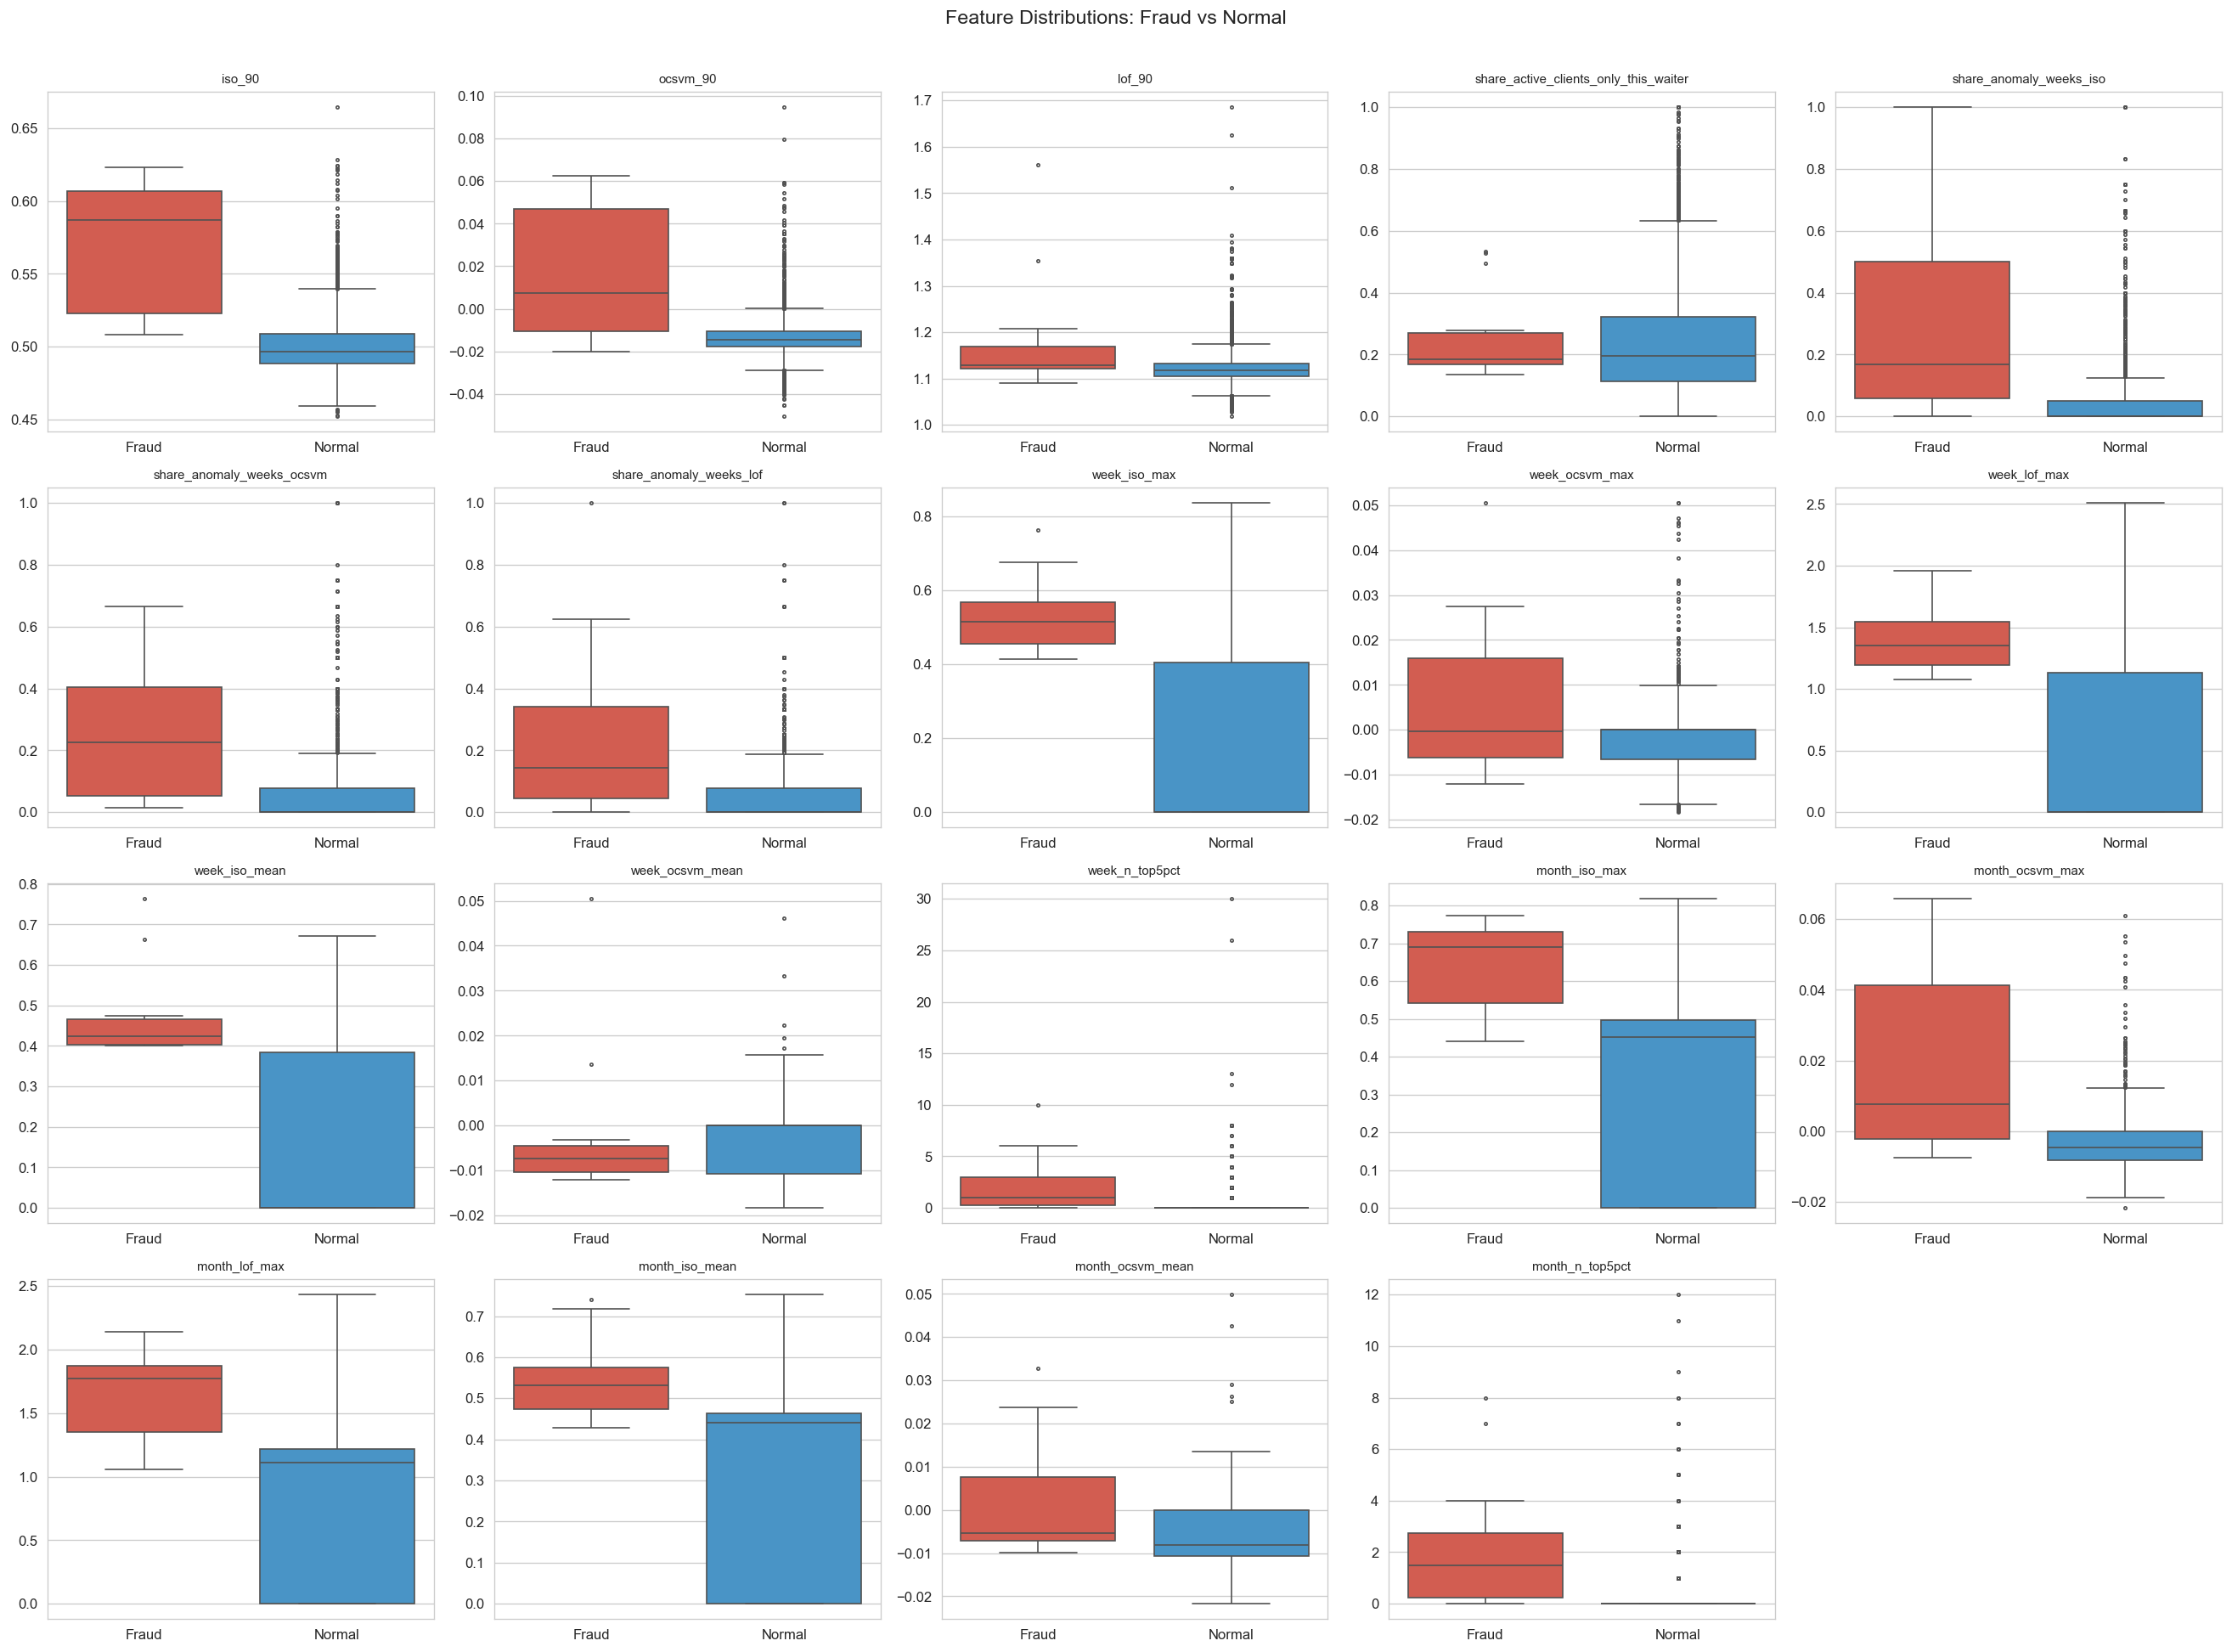

In [29]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes_flat = axes.flatten()

for i, feat in enumerate(ALL_FEATURES):
    ax = axes_flat[i]
    data_plot = pd.DataFrame({
        "value": risk[feat],
        "group": risk["is_fraud"].map({0: "Normal", 1: "Fraud"})
    })
    sns.boxplot(data=data_plot, x="group", y="value", ax=ax,
                palette={"Normal": "#3498db", "Fraud": "#e74c3c"},
                fliersize=2)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

axes_flat[-1].set_visible(False)
fig.suptitle("Feature Distributions: Fraud vs Normal", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Ranking Comparison: OCSVM (unified) vs OCSVM (no-share)

Who enters/leaves top-10 when we remove `share_anomaly_weeks_*`?

In [30]:
rank_baseline = risk.sort_values("score_ocsvm", ascending=False).reset_index(drop=True)
rank_baseline["rank_ocsvm"] = rank_baseline.index + 1

rank_noshare = risk.sort_values("score_ocsvm_no_share", ascending=False).reset_index(drop=True)
rank_noshare["rank_no_share"] = rank_noshare.index + 1

comp = rank_baseline[["waiter_id", "is_fraud", "rank_ocsvm"]].merge(
    rank_noshare[["waiter_id", "rank_no_share"]], on="waiter_id"
)
comp["rank_change"] = comp["rank_ocsvm"] - comp["rank_no_share"]

print("=== Fraud waiter rankings ===")
fraud_comp = comp[comp["is_fraud"] == 1].sort_values("rank_no_share")
print(fraud_comp.to_string(index=False))

top10_base = set(comp[comp["rank_ocsvm"] <= 10]["waiter_id"])
top10_new = set(comp[comp["rank_no_share"] <= 10]["waiter_id"])

entered = top10_new - top10_base
left = top10_base - top10_new
print(f"\nEntered top-10: {entered}")
print(f"Left top-10: {left}")

=== Fraud waiter rankings ===
                     waiter_id  is_fraud  rank_ocsvm  rank_no_share  rank_change
   539f5da6c76b7cd7fa3d859c_56         1           2              1            1
65117ad169a6f4704ea03ecd_18368         1           1              2           -1
   539f5da6c76b7cd7fa3d859c_09         1           4              3            1
 601c0ff64e92a83b9f8413c5_3503         1           3              4           -1
  601c0e3a4e92a83b9f84122c_122         1           5              5            0
601c0e3a4e92a83b9f84122c_16467         1           7              6            1
 54de0d442cdc51c13b68ed82_2045         1          10              7            3
 65117ad169a6f4704ea03ecd_2022         1           9              8            1
 601c0e3a4e92a83b9f84122c_1111         1          11              9            2
 539f5da7c76b7cd7fa3d85af_6094         1         443            373           70
 601c0e3a4e92a83b9f84122c_7536         1         491            470           2

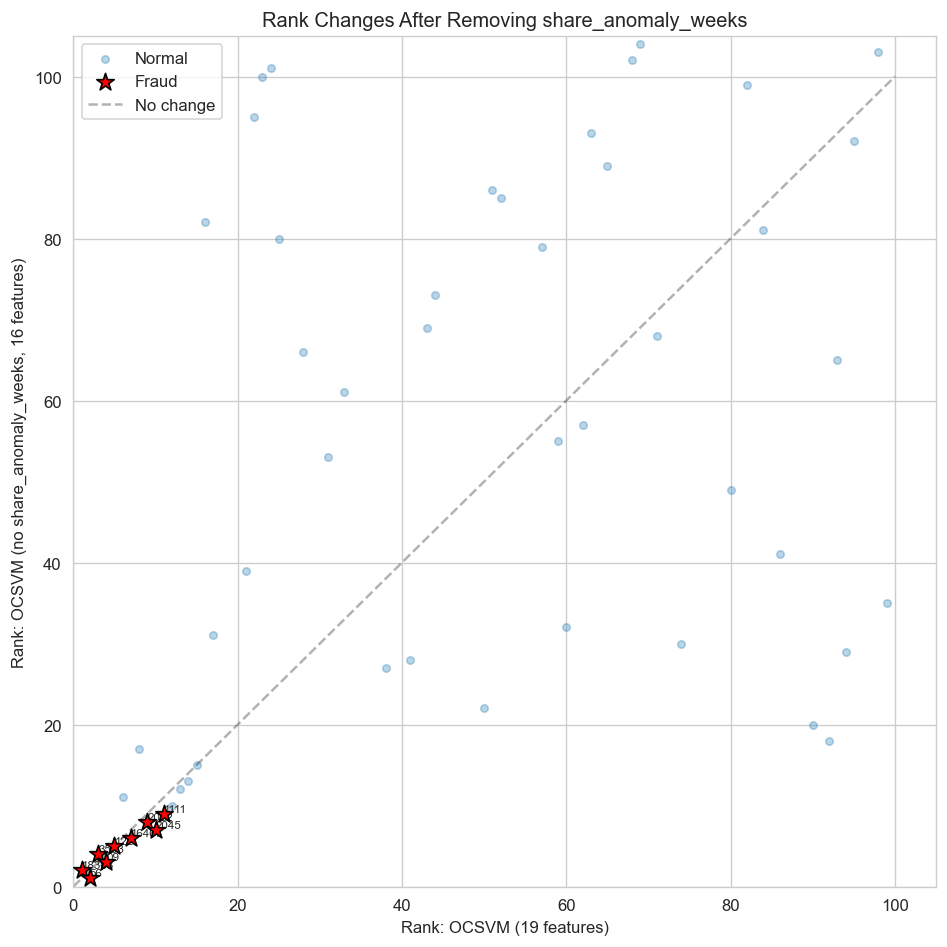

In [31]:
fig, ax = plt.subplots(figsize=(8, 8))

top100 = comp[comp["rank_ocsvm"] <= 100].copy()
norm = top100[top100["is_fraud"] == 0]
fraud = top100[top100["is_fraud"] == 1]

ax.scatter(norm["rank_ocsvm"], norm["rank_no_share"], alpha=0.3, s=20, label="Normal")
ax.scatter(fraud["rank_ocsvm"], fraud["rank_no_share"], c="red", s=120, marker="*",
           edgecolors="black", label="Fraud", zorder=5)

for _, row in fraud.iterrows():
    ax.annotate(row["waiter_id"].split("_")[-1],
                (row["rank_ocsvm"], row["rank_no_share"]),
                fontsize=7, ha="left", va="bottom")

ax.plot([0, 100], [0, 100], "k--", alpha=0.3, label="No change")
ax.set_xlabel("Rank: OCSVM (19 features)")
ax.set_ylabel("Rank: OCSVM (no share_anomaly_weeks, 16 features)")
ax.set_title("Rank Changes After Removing share_anomaly_weeks")
ax.legend()
ax.set_xlim(0, 105)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

## 5. False Positive Analysis: Non-Fraud in Top-10

Which non-fraud waiters rank high? What makes them look anomalous?

In [32]:
top20_noshare = risk.sort_values("score_ocsvm_no_share", ascending=False).head(20).copy()
top20_noshare["rank"] = range(1, 21)

fp = top20_noshare[top20_noshare["is_fraud"] == 0]
print(f"False positives in top-20: {len(fp)}")
print()

features_clean = [f for f in ALL_FEATURES if f not in SHARE_COLS]

for _, row in fp.iterrows():
    print(f"--- Rank {row['rank']}: {row['waiter_id']} ---")
    pctls = risk[features_clean].rank(pct=True)
    idx = risk[risk["waiter_id"] == row["waiter_id"]].index[0]
    top_feats = pctls.loc[idx].sort_values(ascending=False).head(5)
    for feat, pctl in top_feats.items():
        print(f"  {feat}: value={row[feat]:.4f}, percentile={pctl:.3f}")
    print()

False positives in top-20: 11

--- Rank 10: 5eff4aa84e9258a896713d38_1308 ---
  week_ocsvm_mean: value=0.0196, percentile=0.999
  week_ocsvm_max: value=0.0196, percentile=0.994
  week_lof_max: value=1.2712, percentile=0.921
  month_lof_max: value=1.3011, percentile=0.877
  week_iso_mean: value=0.3971, percentile=0.844

--- Rank 11: 5c0a76274e92cab1fd3bbf18_18294 ---
  month_iso_max: value=0.8179, percentile=1.000
  month_iso_mean: value=0.6180, percentile=0.996
  month_n_top5pct: value=4.0000, percentile=0.995
  month_lof_max: value=1.6223, percentile=0.990
  share_active_clients_only_this_waiter: value=0.6094, percentile=0.953

--- Rank 12: 5acf5b8e4e927fcab6fbfd0c_1394 ---
  share_active_clients_only_this_waiter: value=1.0000, percentile=0.999
  month_ocsvm_mean: value=0.0000, percentile=0.844
  month_ocsvm_max: value=0.0000, percentile=0.799
  iso_90: value=0.5122, percentile=0.788
  week_ocsvm_mean: value=0.0000, percentile=0.714

--- Rank 13: 60267b744e9267c273a80a22_32 ---
  iso_

## 6. Undetected Fraud: Who Does the Model Miss?

Fraud waiters ranked below top-14 (i.e., not caught). What are their feature patterns?

In [33]:
rank_best = risk.sort_values("score_ocsvm_no_share", ascending=False).reset_index(drop=True)
rank_best["rank"] = rank_best.index + 1

fraud_all = rank_best[rank_best["is_fraud"] == 1].copy()
detected = fraud_all[fraud_all["rank"] <= 14]
missed = fraud_all[fraud_all["rank"] > 14]

print(f"Detected (rank <= 14): {len(detected)} / {n_fraud}")
print(f"Missed (rank > 14): {len(missed)} / {n_fraud}")
print()
print("Missed fraud waiters:")
print(missed[["rank", "waiter_id"] + features_clean].to_string(index=False))

Detected (rank <= 14): 9 / 14
Missed (rank > 14): 5 / 14

Missed fraud waiters:
 rank                      waiter_id   iso_90  ocsvm_90   lof_90  share_active_clients_only_this_waiter  week_iso_max  week_ocsvm_max  week_lof_max  week_iso_mean  week_ocsvm_mean  week_n_top5pct  month_iso_max  month_ocsvm_max  month_lof_max  month_iso_mean  month_ocsvm_mean  month_n_top5pct
  373  539f5da7c76b7cd7fa3d85af_6094 0.515606 -0.020286 1.120220                               0.173367      0.424479       -0.001743      1.073601       0.402787        -0.006647             0.0       0.455359         0.018613       1.241662        0.432659         -0.006391              0.0
  470  601c0e3a4e92a83b9f84122c_7536 0.518318 -0.008710 1.128529                               0.151645      0.525728       -0.006376      1.564054       0.401509        -0.011195             2.0       0.773754        -0.002747       2.012330        0.516888         -0.009184              3.0
 2357 601c0e3a4e92a83b9f84122c_15933 0

In [34]:
pctls = risk[features_clean].rank(pct=True)
pctls["waiter_id"] = risk["waiter_id"]
pctls["is_fraud"] = risk["is_fraud"]

detected_ids = detected["waiter_id"].values
missed_ids = missed["waiter_id"].values

det_pctls = pctls[pctls["waiter_id"].isin(detected_ids)][features_clean].mean()
miss_pctls = pctls[pctls["waiter_id"].isin(missed_ids)][features_clean].mean()

compare_df = pd.DataFrame({"Detected (avg pctl)": det_pctls, "Missed (avg pctl)": miss_pctls})
compare_df["gap"] = compare_df["Detected (avg pctl)"] - compare_df["Missed (avg pctl)"]
compare_df = compare_df.sort_values("gap", ascending=False)

print("Average feature percentiles: detected vs missed fraud")
print(compare_df.to_string())

Average feature percentiles: detected vs missed fraud
                                       Detected (avg pctl)  Missed (avg pctl)       gap
week_ocsvm_max                                    0.807031           0.278017  0.529015
ocsvm_90                                          0.983261           0.486092  0.497169
month_n_top5pct                                   0.967598           0.552916  0.414682
month_iso_mean                                    0.960331           0.642409  0.317922
month_ocsvm_max                                   0.932677           0.618796  0.313882
month_iso_max                                     0.986593           0.676505  0.310088
month_ocsvm_mean                                  0.817027           0.515702  0.301325
week_n_top5pct                                    0.918641           0.662456  0.256185
month_lof_max                                     0.980559           0.743424  0.237135
share_active_clients_only_this_waiter             0.635249        

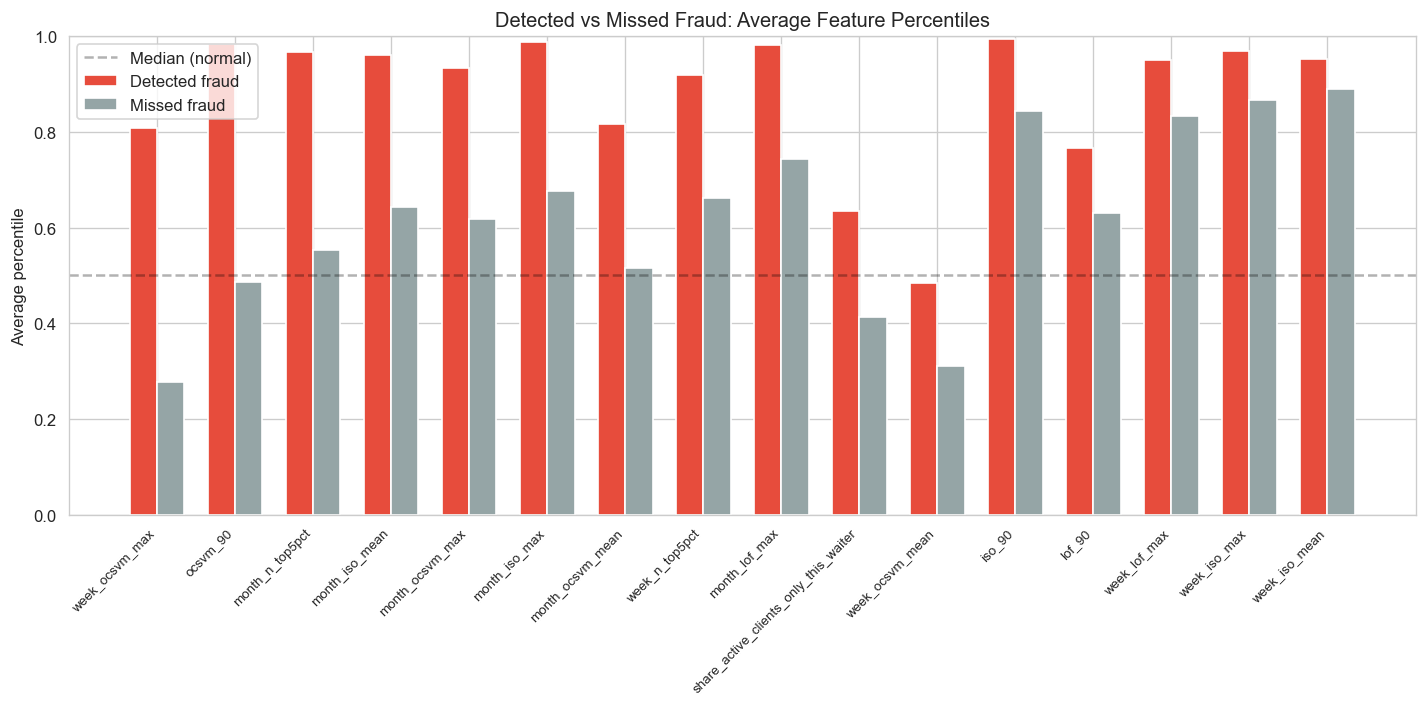

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(compare_df))
w = 0.35
ax.bar(x - w/2, compare_df["Detected (avg pctl)"], w, label="Detected fraud", color="#e74c3c")
ax.bar(x + w/2, compare_df["Missed (avg pctl)"], w, label="Missed fraud", color="#95a5a6")
ax.axhline(0.5, color="black", linestyle="--", alpha=0.3, label="Median (normal)")
ax.set_xticks(x)
ax.set_xticklabels(compare_df.index, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Average percentile")
ax.set_title("Detected vs Missed Fraud: Average Feature Percentiles")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 7. Feature Percentile Heatmap: All Fraud Waiters

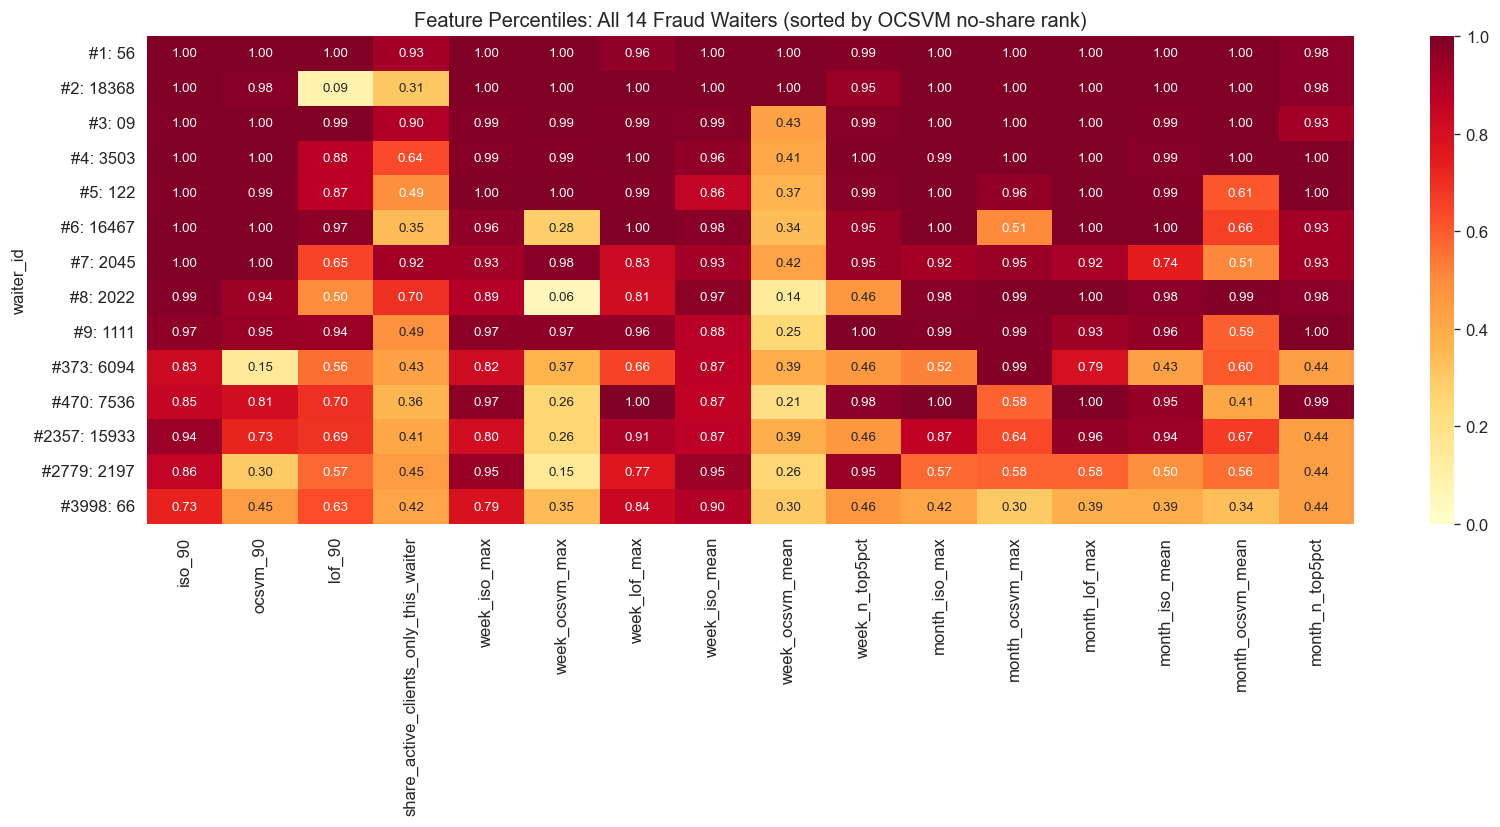

In [36]:
fraud_ranked = rank_best[rank_best["is_fraud"] == 1].sort_values("rank")
fraud_ids_ordered = fraud_ranked["waiter_id"].values

pctl_fraud = pctls[pctls["waiter_id"].isin(fraud_ids_ordered)].copy()
pctl_fraud = pctl_fraud.set_index("waiter_id").loc[fraud_ids_ordered]

labels = [f"#{int(fraud_ranked[fraud_ranked['waiter_id']==wid]['rank'].values[0])}: "
          f"{wid.split('_')[-1]}" for wid in fraud_ids_ordered]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pctl_fraud[features_clean], annot=True, fmt=".2f",
            cmap="YlOrRd", ax=ax, vmin=0, vmax=1,
            yticklabels=labels, annot_kws={"size": 8})
ax.set_title("Feature Percentiles: All 14 Fraud Waiters (sorted by OCSVM no-share rank)")
plt.tight_layout()
plt.show()

## 8. Missed Fraud: Individual Profiles

In [37]:
for _, row in missed.iterrows():
    wid = row["waiter_id"]
    rank = int(row["rank"])
    idx = risk[risk["waiter_id"] == wid].index[0]
    
    print(f"\n{'='*60}")
    print(f"Fraud waiter: {wid} (rank #{rank})")
    print(f"{'='*60}")
    
    waiter_pctls = pctls.loc[idx, features_clean].sort_values(ascending=False)
    print("\nFeature percentiles (highest first):")
    for feat, p in waiter_pctls.items():
        marker = "!!" if p > 0.95 else "!" if p > 0.9 else "  "
        print(f"  {marker} {feat}: {p:.3f} (value: {row[feat]:.4f})")
    
    high_pctl = (waiter_pctls > 0.9).sum()
    print(f"\nFeatures above 90th percentile: {high_pctl} / {len(features_clean)}")


Fraud waiter: 539f5da7c76b7cd7fa3d85af_6094 (rank #373)

Feature percentiles (highest first):
  !! month_ocsvm_max: 0.991 (value: 0.0186)
     week_iso_mean: 0.872 (value: 0.4028)
     iso_90: 0.828 (value: 0.5156)
     week_iso_max: 0.823 (value: 0.4245)
     month_lof_max: 0.793 (value: 1.2417)
     week_lof_max: 0.656 (value: 1.0736)
     month_ocsvm_mean: 0.604 (value: -0.0064)
     lof_90: 0.561 (value: 1.1202)
     month_iso_max: 0.523 (value: 0.4554)
     week_n_top5pct: 0.462 (value: 0.0000)
     month_n_top5pct: 0.443 (value: 0.0000)
     month_iso_mean: 0.430 (value: 0.4327)
     share_active_clients_only_this_waiter: 0.427 (value: 0.1734)
     week_ocsvm_mean: 0.393 (value: -0.0066)
     week_ocsvm_max: 0.372 (value: -0.0017)
     ocsvm_90: 0.148 (value: -0.0203)

Features above 90th percentile: 1 / 16

Fraud waiter: 601c0e3a4e92a83b9f84122c_7536 (rank #470)

Feature percentiles (highest first):
  !! month_iso_max: 0.999 (value: 0.7738)
  !! month_lof_max: 0.999 (value: 2.0

## 9. Precision@k Comparison: All Approaches

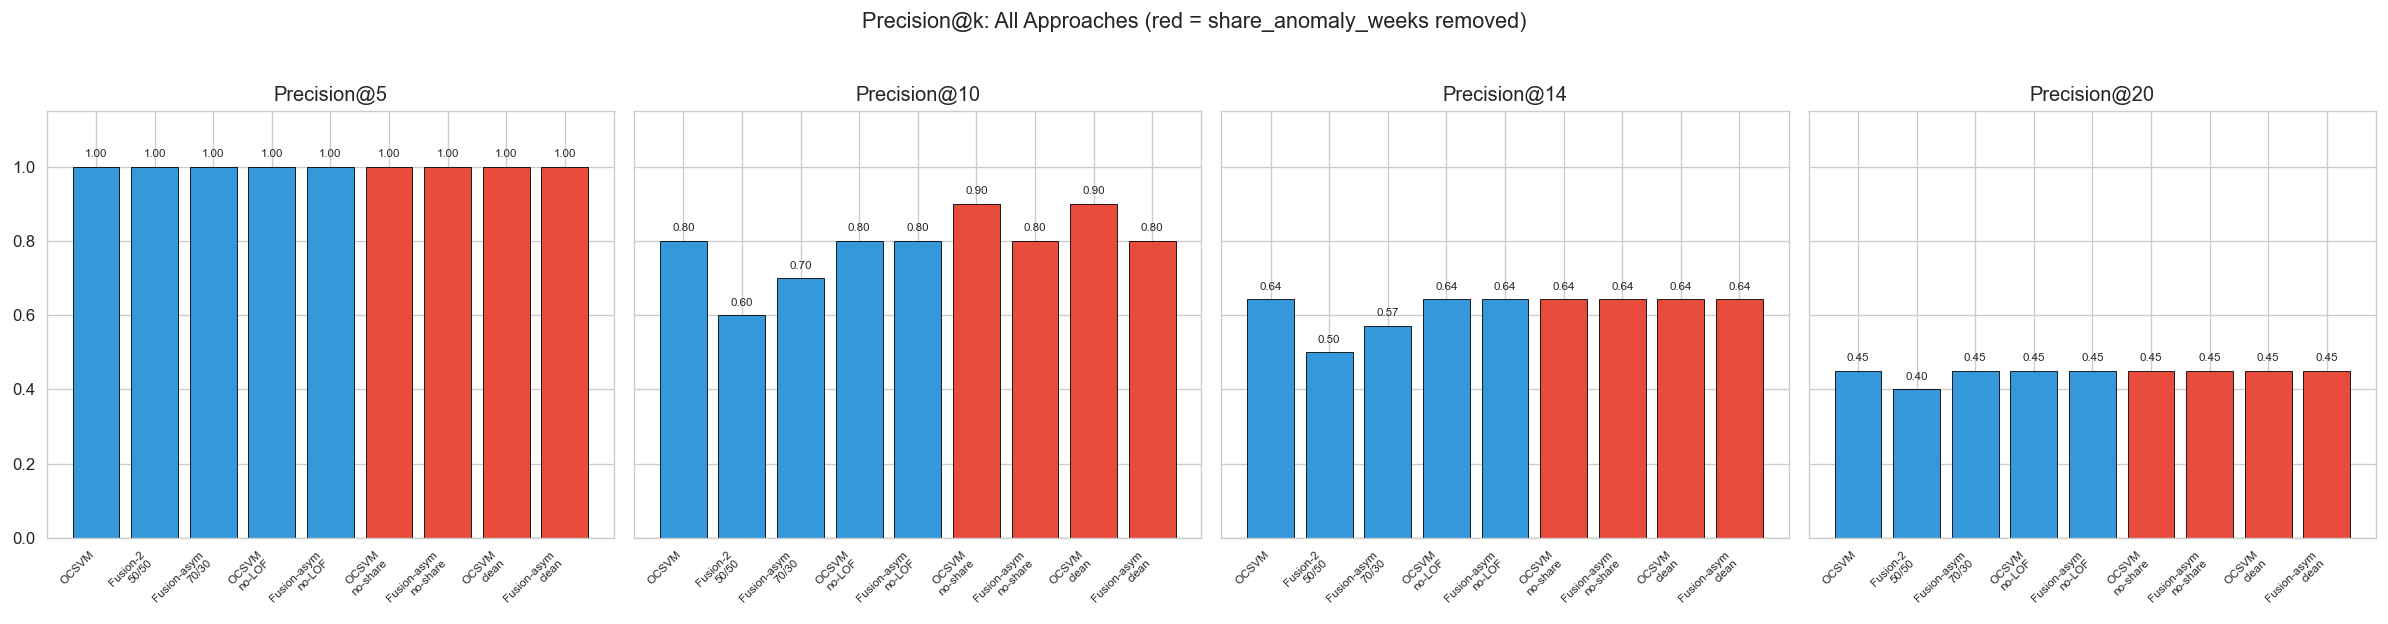

In [38]:
approaches = {
    "OCSVM": "score_ocsvm",
    "Fusion-2\n50/50": "score_fusion2",
    "Fusion-asym\n70/30": "score_fusion_asym",
    "OCSVM\nno-LOF": "score_ocsvm_no_lof",
    "Fusion-asym\nno-LOF": "score_fusion_asym_no_lof",
    "OCSVM\nno-share": "score_ocsvm_no_share",
    "Fusion-asym\nno-share": "score_fusion_asym_no_share",
    "OCSVM\nclean": "score_ocsvm_clean",
    "Fusion-asym\nclean": "score_fusion_asym_clean",
}

ks = [5, 10, 14, 20]
results = []
for label, col in approaches.items():
    ranked = risk.sort_values(col, ascending=False).reset_index(drop=True)
    for k in ks:
        fraud_in_top = ranked.head(k)["is_fraud"].sum()
        results.append({"approach": label, "k": k, "precision": fraud_in_top / k})

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, k in zip(axes, ks):
    data = res_df[res_df["k"] == k]
    colors = ["#e74c3c" if "no-share" in a or "clean" in a else "#3498db"
              for a in data["approach"]]
    bars = ax.bar(range(len(data)), data["precision"], color=colors,
                  edgecolor="black", linewidth=0.5)
    ax.set_title(f"Precision@{k}", fontsize=12)
    ax.set_ylim(0, 1.15)
    ax.set_xticks(range(len(data)))
    ax.set_xticklabels(data["approach"], fontsize=7, rotation=45, ha="right")
    for bar, val in zip(bars, data["precision"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7)

fig.suptitle("Precision@k: All Approaches (red = share_anomaly_weeks removed)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

## 10. ROC AUC Curves: All 16 Ensemble Approaches

Grouped by feature set:
- **Baseline** (19 features): IF, OCSVM, LOF, Fusion-2, Fusion-asym, Fusion-sig
- **No-LOF** (15 features): IF, OCSVM, Fusion-2, Fusion-asym
- **Smart** (18 features, only card LOF removed): OCSVM, Fusion-asym
- **No-share** (16 features, share_anomaly_weeks removed): OCSVM, Fusion-asym
- **Clean** (no LOF + no share, 12 features): OCSVM, Fusion-asym

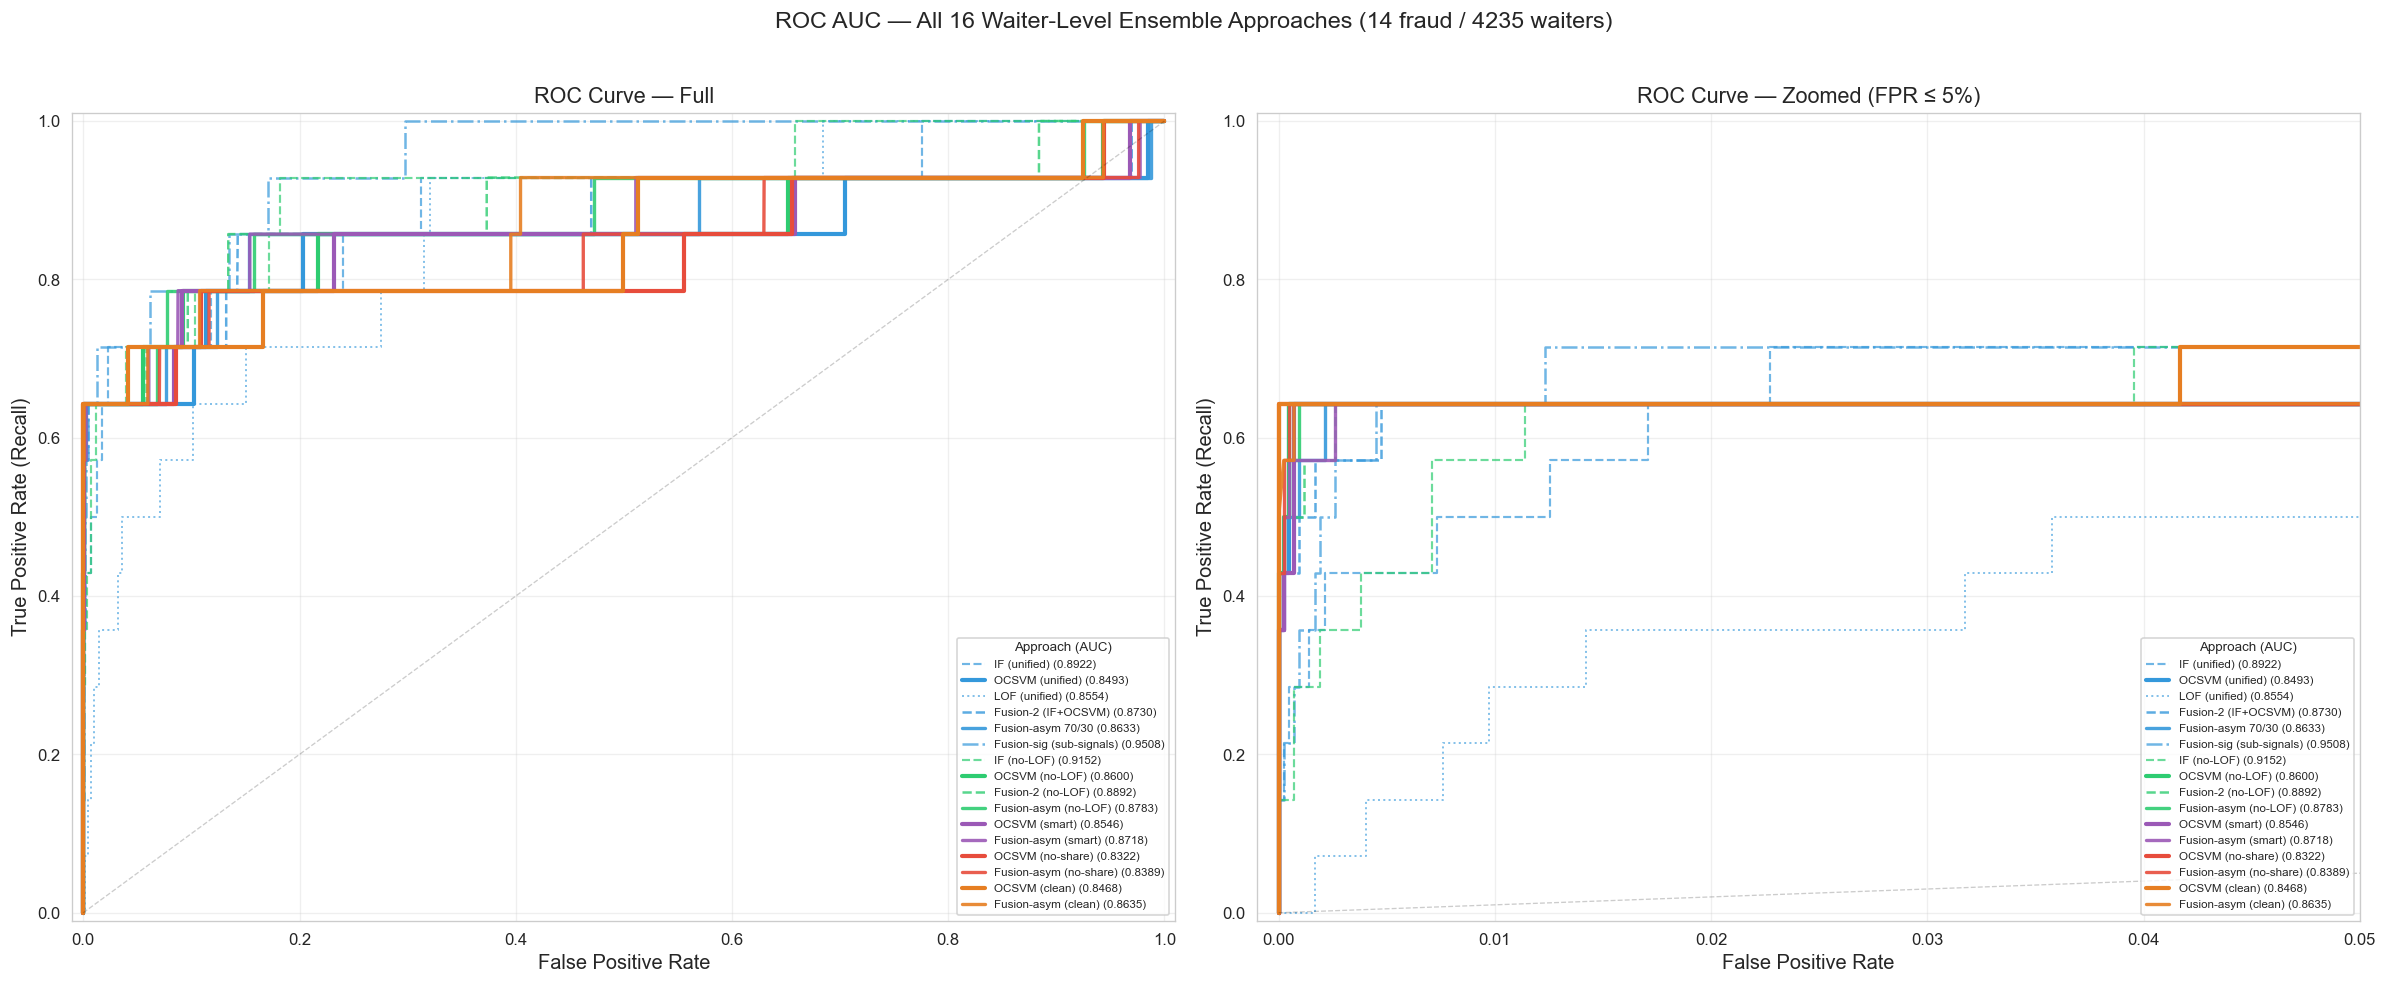


AUC Summary (sorted by AUC):
  Approach                             AUC
  ------------------------------  --------
  Fusion-sig (sub-signals)        0.9508
  IF (no-LOF)                     0.9152
  IF (unified)                    0.8922
  Fusion-2 (no-LOF)               0.8892
  Fusion-asym (no-LOF)            0.8783
  Fusion-2 (IF+OCSVM)             0.8730
  Fusion-asym (smart)             0.8718
  Fusion-asym (clean)             0.8635
  Fusion-asym 70/30               0.8633
  OCSVM (no-LOF)                  0.8600
  LOF (unified)                   0.8554
  OCSVM (smart)                   0.8546
  OCSVM (unified)                 0.8493
  OCSVM (clean)                   0.8468
  Fusion-asym (no-share)          0.8389
  OCSVM (no-share)                0.8322


In [39]:
from sklearn.metrics import roc_curve, auc
from collections import OrderedDict

all_approaches = OrderedDict([
    # Baseline (19 features)
    ("IF (unified)",              "score_if"),
    ("OCSVM (unified)",           "score_ocsvm"),
    ("LOF (unified)",             "score_lof"),
    ("Fusion-2 (IF+OCSVM)",      "score_fusion2"),
    ("Fusion-asym 70/30",        "score_fusion_asym"),
    ("Fusion-sig (sub-signals)", "score_fusion_sig"),
    # No-LOF (15 features)
    ("IF (no-LOF)",              "score_if_no_lof"),
    ("OCSVM (no-LOF)",           "score_ocsvm_no_lof"),
    ("Fusion-2 (no-LOF)",       "score_fusion2_no_lof"),
    ("Fusion-asym (no-LOF)",    "score_fusion_asym_no_lof"),
    # Smart (18 features)
    ("OCSVM (smart)",            "score_ocsvm_smart"),
    ("Fusion-asym (smart)",     "score_fusion_asym_smart"),
    # No-share (16 features)
    ("OCSVM (no-share)",         "score_ocsvm_no_share"),
    ("Fusion-asym (no-share)",  "score_fusion_asym_no_share"),
    # Clean (12 features)
    ("OCSVM (clean)",            "score_ocsvm_clean"),
    ("Fusion-asym (clean)",     "score_fusion_asym_clean"),
])

group_colors = {
    "baseline": "#3498db",
    "no_lof":   "#2ecc71",
    "smart":    "#9b59b6",
    "no_share": "#e74c3c",
    "clean":    "#e67e22",
}

def _get_style(label):
    if "no-LOF" in label:
        base = group_colors["no_lof"]
    elif "smart" in label:
        base = group_colors["smart"]
    elif "no-share" in label:
        base = group_colors["no_share"]
    elif "clean" in label:
        base = group_colors["clean"]
    else:
        base = group_colors["baseline"]

    if "LOF" in label and "no-LOF" not in label and "Fusion" not in label:
        ls, lw, alpha = ":", 1.2, 0.6
    elif "Fusion-sig" in label:
        ls, lw, alpha = "-.", 1.5, 0.7
    elif "Fusion-2" in label:
        ls, lw, alpha = "--", 1.5, 0.8
    elif "Fusion-asym" in label:
        ls, lw, alpha = "-", 2.0, 0.9
    elif "IF" in label:
        ls, lw, alpha = "--", 1.3, 0.7
    else:  # OCSVM standalone
        ls, lw, alpha = "-", 2.5, 1.0
    return base, ls, lw, alpha

y_true = risk["is_fraud"].values

auc_results = {}
for label, col in all_approaches.items():
    fpr, tpr, _ = roc_curve(y_true, risk[col].values)
    auc_results[label] = (fpr, tpr, auc(fpr, tpr))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, (xlim, title_suffix) in zip(axes, [
    ([-0.01, 1.01], "Full"),
    ([-0.001, 0.05], "Zoomed (FPR ≤ 5%)"),
]):
    for label in all_approaches:
        fpr, tpr, roc_auc = auc_results[label]
        color, ls, lw, alpha = _get_style(label)
        ax.plot(fpr, tpr, color=color, ls=ls, lw=lw, alpha=alpha,
                label=f"{label} ({roc_auc:.4f})")

    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
    ax.set_title(f"ROC Curve — {title_suffix}", fontsize=13)
    ax.set_xlim(xlim)
    ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=7, title="Approach (AUC)", title_fontsize=8)

fig.suptitle("ROC AUC — All 16 Waiter-Level Ensemble Approaches (14 fraud / 4235 waiters)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("roc_auc_waiter_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAUC Summary (sorted by AUC):")
print(f"  {'Approach':<30s}  {'AUC':>8s}")
print(f"  {'-'*30}  {'-'*8}")
for label, (_, _, roc_auc) in sorted(auc_results.items(), key=lambda x: -x[1][2]):
    print(f"  {label:<30s}  {roc_auc:.4f}")

## 11. Synthetic Fraud Validation: ROC AUC

Generate synthetic fraud waiters by perturbing the 14 real ones (resample with replacement + Gaussian noise). Fit models on non-fraud only, score non-fraud + synthetic, compute ROC AUC.

Multiple noise levels test model robustness:
- **5%** — near-copies of real fraud (easy)
- **10%** — moderate perturbations
- **20%** — significant variation
- **50%** — extreme perturbation (hard)

In [40]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

FEATURES_NO_SHARE = [f for f in ALL_FEATURES if f not in SHARE_COLS]

fraud_rows = risk[risk["is_fraud"] == 1]
non_fraud_rows = risk[risk["is_fraud"] == 0]

N_SYNTHETIC = 200
NOISE_LEVELS = [0.05, 0.10, 0.20, 0.50]

nf_std = non_fraud_rows[FEATURES_NO_SHARE].std().values

def generate_synthetic_fraud(fraud_df, features, n_synthetic, noise_scale, nf_std, seed=42):
    rng = np.random.default_rng(seed)
    sampled = fraud_df[features].sample(n=n_synthetic, replace=True, random_state=seed)
    noise = rng.normal(0, 1, sampled.shape) * (noise_scale * nf_std)
    synthetic = sampled.values + noise
    return pd.DataFrame(synthetic, columns=features)

# --- log1p for skewed features (same logic as scale_features) ---
X_nf_raw = non_fraud_rows[FEATURES_NO_SHARE].copy()
skewed_cols = [c for c in FEATURES_NO_SHARE
               if abs(X_nf_raw[c].skew()) >= 1.0
               and not (X_nf_raw[c].min() >= 0 and X_nf_raw[c].max() <= 1)]

def apply_log1p_safe(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = np.log1p(np.clip(out[c], 0, None))
    out = out.replace([np.inf, -np.inf], np.nan).fillna(0)
    return out

X_nf = apply_log1p_safe(non_fraud_rows[FEATURES_NO_SHARE], skewed_cols)
scaler = StandardScaler().fit(X_nf)
X_nf_scaled = scaler.transform(X_nf)

# --- fit models on non-fraud (same params as pipeline) ---
models = {
    "IF": IsolationForest(n_estimators=200, contamination=0.0005, random_state=42, n_jobs=-1),
    "OCSVM": OneClassSVM(kernel="rbf", nu=0.0005, gamma="scale"),
    "LOF": LocalOutlierFactor(n_neighbors=10, contamination=0.01, novelty=True),
}

rng_ocsvm = np.random.default_rng(42)
max_ocsvm_train = 4000
if len(X_nf_scaled) > max_ocsvm_train:
    ocsvm_idx = rng_ocsvm.choice(len(X_nf_scaled), size=max_ocsvm_train, replace=False)
    X_ocsvm_fit = X_nf_scaled[ocsvm_idx]
else:
    X_ocsvm_fit = X_nf_scaled

models["IF"].fit(X_nf_scaled)
models["OCSVM"].fit(X_ocsvm_fit)
models["LOF"].fit(X_nf_scaled)

print(f"Models fitted on {len(X_nf_scaled)} non-fraud waiters")
print(f"Features ({len(FEATURES_NO_SHARE)}): {FEATURES_NO_SHARE}")
print(f"Skewed (log1p applied): {skewed_cols}")
print(f"\nNoise type: additive, calibrated to non-fraud std")
print(f"  noise_scale=0.1 → add N(0, 0.1 * std_nf) to each feature")
print(f"  Higher noise → synthetic fraud drifts toward normal → harder to detect")

# --- score for each noise level ---
roc_data = {}
for noise in NOISE_LEVELS:
    synth = generate_synthetic_fraud(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std)
    synth = apply_log1p_safe(synth, skewed_cols)
    X_synth_scaled = scaler.transform(synth)

    X_all = np.vstack([X_nf_scaled, X_synth_scaled])
    y_all = np.concatenate([np.zeros(len(X_nf_scaled)), np.ones(N_SYNTHETIC)])

    roc_data[noise] = {}
    for name, model in models.items():
        if name == "IF":
            scores = -model.score_samples(X_all)
        elif name == "OCSVM":
            scores = -model.decision_function(X_all)
        else:
            scores = -model.score_samples(X_all)
        fpr, tpr, _ = roc_curve(y_all, scores)
        roc_auc = auc(fpr, tpr)
        roc_data[noise][name] = (fpr, tpr, roc_auc)

    print(f"\nNoise {noise:.0%}: IF={roc_data[noise]['IF'][2]:.4f}, "
          f"OCSVM={roc_data[noise]['OCSVM'][2]:.4f}, "
          f"LOF={roc_data[noise]['LOF'][2]:.4f}")

Models fitted on 4221 non-fraud waiters
Features (16): ['iso_90', 'ocsvm_90', 'lof_90', 'share_active_clients_only_this_waiter', 'week_iso_max', 'week_ocsvm_max', 'week_lof_max', 'week_iso_mean', 'week_ocsvm_mean', 'week_n_top5pct', 'month_iso_max', 'month_ocsvm_max', 'month_lof_max', 'month_iso_mean', 'month_ocsvm_mean', 'month_n_top5pct']
Skewed (log1p applied): ['ocsvm_90', 'lof_90', 'week_ocsvm_max', 'week_n_top5pct', 'month_ocsvm_max', 'month_n_top5pct']

Noise type: additive, calibrated to non-fraud std
  noise_scale=0.1 → add N(0, 0.1 * std_nf) to each feature
  Higher noise → synthetic fraud drifts toward normal → harder to detect

Noise 5%: IF=0.8822, OCSVM=0.7916, LOF=0.8237

Noise 10%: IF=0.8931, OCSVM=0.7901, LOF=0.8409

Noise 20%: IF=0.9122, OCSVM=0.7990, LOF=0.8725

Noise 50%: IF=0.9517, OCSVM=0.8818, LOF=0.9384


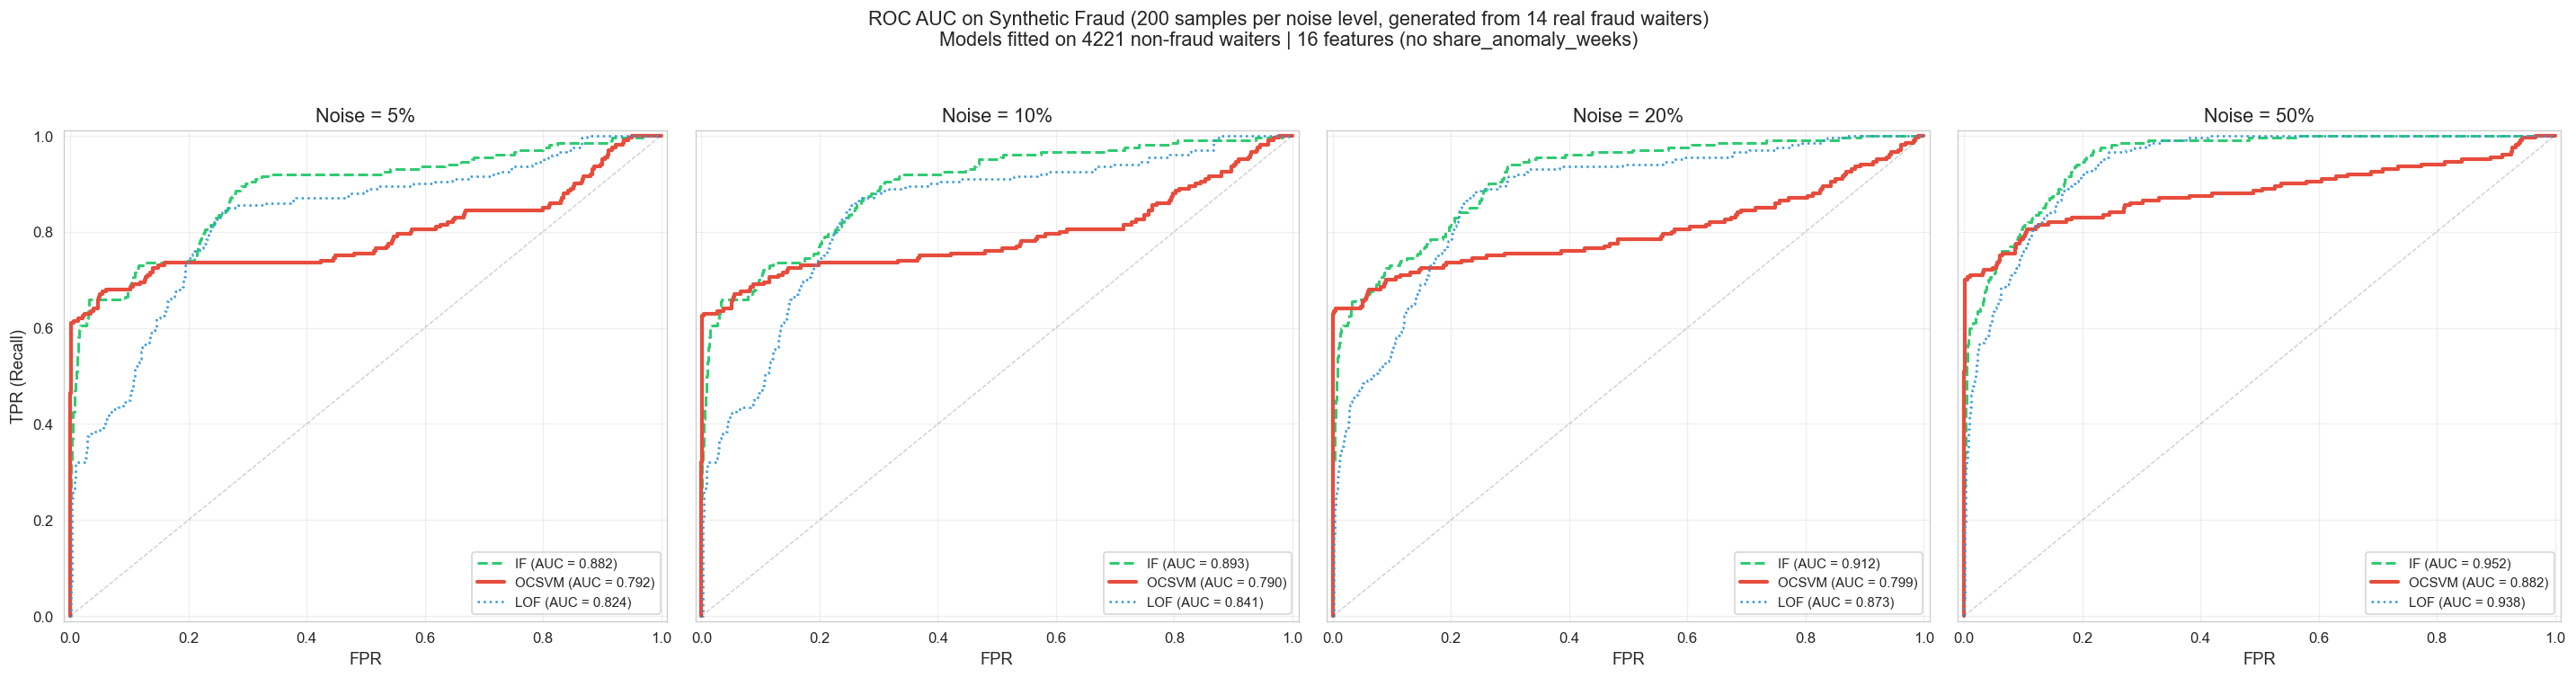

In [41]:
model_colors = {"IF": "#2ecc71", "OCSVM": "#e74c3c", "LOF": "#3498db"}
model_lw = {"IF": 1.8, "OCSVM": 2.5, "LOF": 1.5}
model_ls = {"IF": "--", "OCSVM": "-", "LOF": ":"}

fig, axes = plt.subplots(1, len(NOISE_LEVELS), figsize=(24, 6), sharey=True)

for ax, noise in zip(axes, NOISE_LEVELS):
    for name in ["IF", "OCSVM", "LOF"]:
        fpr, tpr, roc_auc = roc_data[noise][name]
        ax.plot(fpr, tpr, color=model_colors[name], lw=model_lw[name],
                ls=model_ls[name], label=f"{name} (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_title(f"Noise = {noise:.0%}", fontsize=13)
    ax.set_xlabel("FPR", fontsize=11)
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("TPR (Recall)", fontsize=11)
fig.suptitle(f"ROC AUC on Synthetic Fraud ({N_SYNTHETIC} samples per noise level, "
             f"generated from 14 real fraud waiters)\n"
             f"Models fitted on {len(X_nf_scaled)} non-fraud waiters | "
             f"{len(FEATURES_NO_SHARE)} features (no share_anomaly_weeks)",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("roc_auc_synthetic_fraud.png", dpi=150, bbox_inches="tight")
plt.show()

AUC by noise level:
           IF   OCSVM     LOF
noise                        
5%     0.8822  0.7916  0.8237
10%    0.8931  0.7901  0.8409
20%    0.9122  0.7990  0.8725
50%    0.9517  0.8818  0.9384


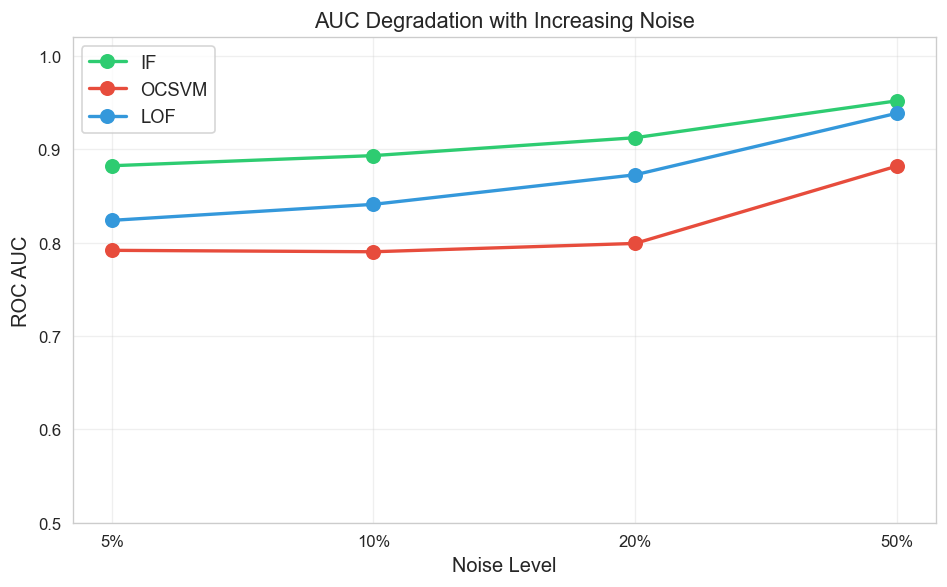

In [42]:
# --- AUC degradation summary ---
summary_rows = []
for noise in NOISE_LEVELS:
    row = {"noise": f"{noise:.0%}"}
    for name in ["IF", "OCSVM", "LOF"]:
        row[name] = roc_data[noise][name][2]
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("noise")
print("AUC by noise level:")
print(summary_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["IF", "OCSVM", "LOF"]:
    vals = [roc_data[n][name][2] for n in NOISE_LEVELS]
    ax.plot([f"{n:.0%}" for n in NOISE_LEVELS], vals,
            "o-", color=model_colors[name], lw=2, ms=8, label=name)

ax.set_xlabel("Noise Level", fontsize=12)
ax.set_ylabel("ROC AUC", fontsize=12)
ax.set_title("AUC Degradation with Increasing Noise", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim([0.5, 1.02])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("auc_degradation_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()

### 11a. Diagnostic: Why Does AUC Increase With Noise?

The problem: additive noise pushes some feature values **beyond** the non-fraud range, creating artificial outliers that are trivially detectable. This chart shows what percentage of synthetic values fall outside the non-fraud [p1, p99] range per feature per noise level.

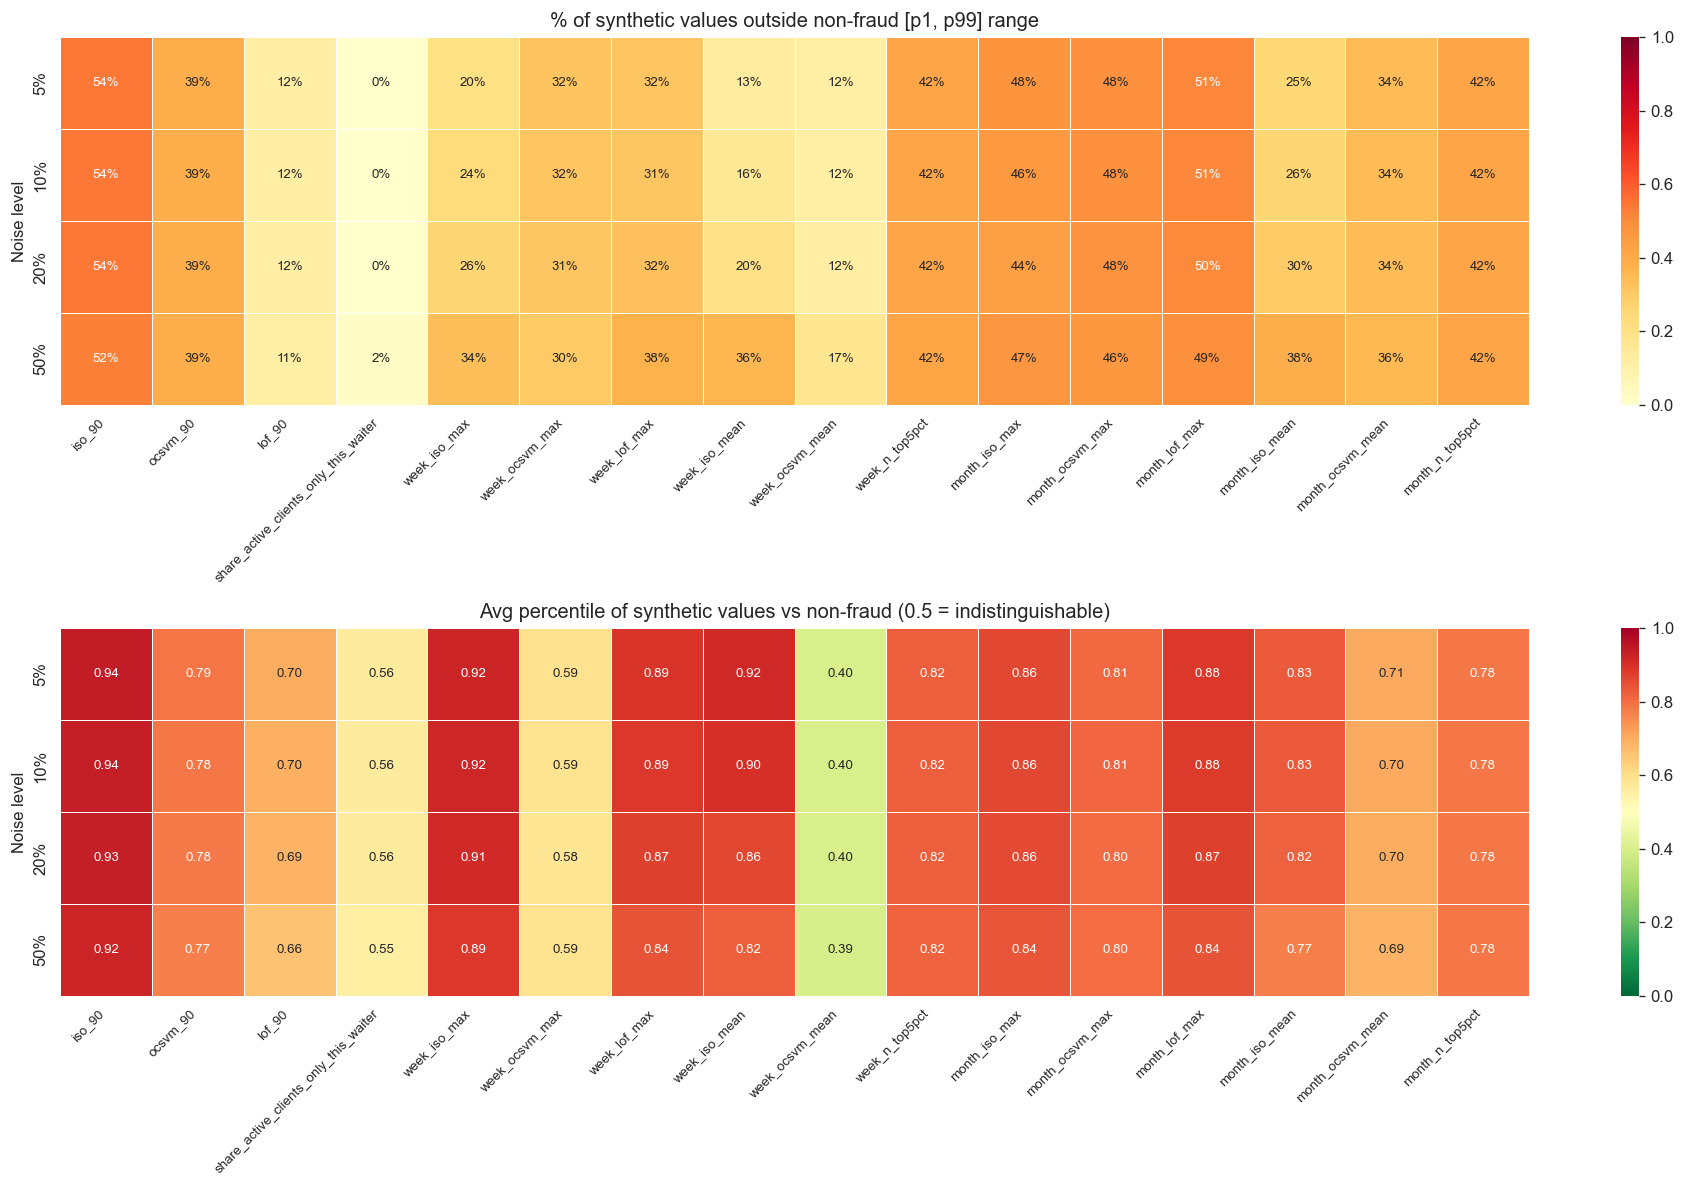


Features where >30% of synthetic values are out-of-range at noise=50%:
  iso_90: 52% OOR | fraud_mean=0.5698, nf_mean=0.5007, nf_std=0.0194
  month_lof_max: 49% OOR | fraud_mean=1.6229, nf_mean=0.8478, nf_std=0.5536
  month_iso_max: 47% OOR | fraud_mean=0.6371, nf_mean=0.3468, nf_std=0.2262
  month_ocsvm_max: 46% OOR | fraud_mean=0.0184, nf_mean=-0.0043, nf_std=0.0058
  week_n_top5pct: 42% OOR | fraud_mean=2.2857, nf_mean=0.1530, nf_std=0.9220
  month_n_top5pct: 42% OOR | fraud_mean=2.2143, nf_mean=0.1699, nf_std=0.6386
  ocsvm_90: 39% OOR | fraud_mean=0.0172, nf_mean=-0.0134, nf_std=0.0095
  month_iso_mean: 38% OOR | fraud_mean=0.5491, nf_mean=0.3268, nf_std=0.2106
  week_lof_max: 38% OOR | fraud_mean=1.4033, nf_mean=0.5260, nf_std=0.5871
  week_iso_mean: 36% OOR | fraud_mean=0.4666, nf_mean=0.1781, nf_std=0.1978
  month_ocsvm_mean: 36% OOR | fraud_mean=0.0018, nf_mean=-0.0066, nf_std=0.0053
  week_iso_max: 34% OOR | fraud_mean=0.5301, nf_mean=0.1913, nf_std=0.2143


In [43]:
# 1) Out-of-range heatmap: % of synthetic values outside non-fraud [p1, p99]
nf_p01 = non_fraud_rows[FEATURES_NO_SHARE].quantile(0.01)
nf_p99 = non_fraud_rows[FEATURES_NO_SHARE].quantile(0.99)
nf_mean = non_fraud_rows[FEATURES_NO_SHARE].mean()
fraud_mean = fraud_rows[FEATURES_NO_SHARE].mean()

oor_data = {}
pctl_data = {}
for noise in NOISE_LEVELS:
    synth = generate_synthetic_fraud(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std)
    oor_row = {}
    pctl_row = {}
    for feat in FEATURES_NO_SHARE:
        vals = synth[feat].values
        below = (vals < nf_p01[feat]).mean()
        above = (vals > nf_p99[feat]).mean()
        oor_row[feat] = above + below
        pctl_row[feat] = (non_fraud_rows[feat].values[:, None] < vals[None, :]).mean(axis=0).mean()
    oor_data[f"{noise:.0%}"] = oor_row
    pctl_data[f"{noise:.0%}"] = pctl_row

oor_df = pd.DataFrame(oor_data).T
pctl_df = pd.DataFrame(pctl_data).T

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Heatmap 1: out-of-range %
sns.heatmap(oor_df, annot=True, fmt=".0%", cmap="YlOrRd", ax=axes[0],
            vmin=0, vmax=1, linewidths=0.5, annot_kws={"size": 8})
axes[0].set_title("% of synthetic values outside non-fraud [p1, p99] range", fontsize=12)
axes[0].set_ylabel("Noise level")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right", fontsize=8)

# Heatmap 2: avg percentile vs non-fraud
sns.heatmap(pctl_df, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=axes[1],
            vmin=0, vmax=1, center=0.5, linewidths=0.5, annot_kws={"size": 8})
axes[1].set_title("Avg percentile of synthetic values vs non-fraud (0.5 = indistinguishable)", fontsize=12)
axes[1].set_ylabel("Noise level")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("synthetic_diagnostic_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary: which features are problematic?
print("\nFeatures where >30% of synthetic values are out-of-range at noise=50%:")
worst = oor_df.loc["50%"].sort_values(ascending=False)
for feat, pct in worst.items():
    if pct > 0.3:
        print(f"  {feat}: {pct:.0%} OOR | fraud_mean={fraud_mean[feat]:.4f}, "
              f"nf_mean={nf_mean[feat]:.4f}, nf_std={non_fraud_rows[feat].std():.4f}")

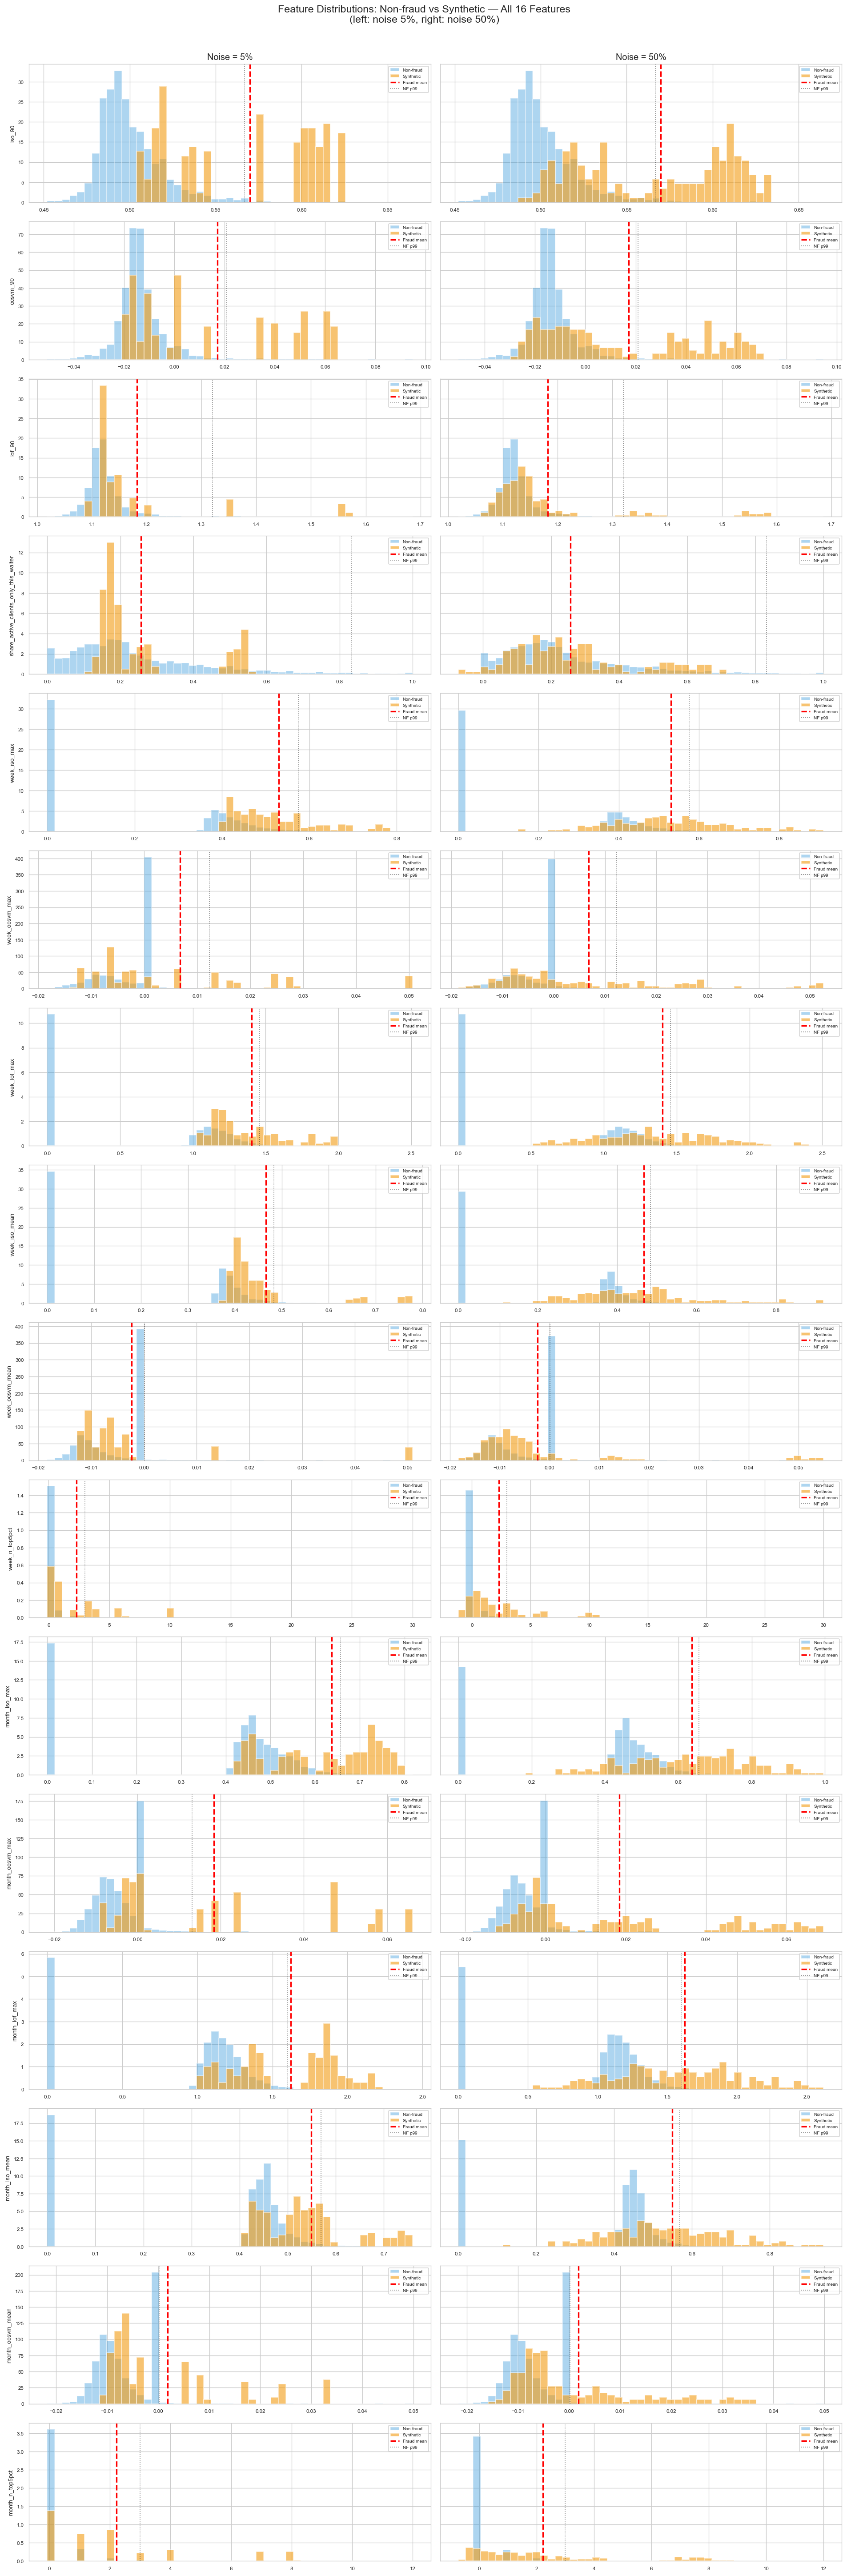

In [44]:
# 2) Distributions for ALL 16 features at noise=5% vs 50%
fig, axes = plt.subplots(len(FEATURES_NO_SHARE), 2, figsize=(16, 3 * len(FEATURES_NO_SHARE)),
                         sharey="row")

for row_idx, feat in enumerate(FEATURES_NO_SHARE):
    for col_idx, noise in enumerate([0.05, 0.50]):
        ax = axes[row_idx][col_idx]
        synth = generate_synthetic_fraud(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std)

        nf_vals = non_fraud_rows[feat].values
        synth_vals = synth[feat].values
        fraud_vals = fraud_rows[feat].values

        lo = min(nf_vals.min(), synth_vals.min(), fraud_vals.min())
        hi = max(nf_vals.max(), synth_vals.max(), fraud_vals.max())
        bins = np.linspace(lo, hi, 50)

        ax.hist(nf_vals, bins=bins, alpha=0.4, color="#3498db", density=True, label="Non-fraud")
        ax.hist(synth_vals, bins=bins, alpha=0.6, color="#f39c12", density=True, label="Synthetic")
        ax.axvline(fraud_vals.mean(), color="red", lw=2, ls="--", label="Fraud mean")
        ax.axvline(nf_p99[feat], color="black", lw=1, ls=":", alpha=0.5, label="NF p99")

        if row_idx == 0:
            ax.set_title(f"Noise = {noise:.0%}", fontsize=12)
        ax.set_ylabel(feat, fontsize=8) if col_idx == 0 else ax.set_ylabel("")
        ax.legend(fontsize=6, loc="upper right")
        ax.tick_params(labelsize=7)

fig.suptitle("Feature Distributions: Non-fraud vs Synthetic — All 16 Features\n"
             "(left: noise 5%, right: noise 50%)",
             fontsize=14, y=1.005)
plt.tight_layout()
plt.savefig("synthetic_all_features_histograms.png", dpi=120, bbox_inches="tight")
plt.show()

## 12. Improved Synthetic Fraud: Clamped vs Interpolation

Two approaches that keep synthetic values **within realistic bounds**:

**A) Clamped noise** — same additive noise, but clamp each feature to [min_fraud, max_fraud] observed range. Prevents out-of-range artifacts.

**B) Interpolation** — blend fraud with random non-fraud: `synth = (1-α)*fraud + α*random_normal`. α=0 is pure fraud, α=1 is pure normal. No out-of-range values by construction.

In [45]:
# --- A) Clamped noise ---
fraud_min = fraud_rows[FEATURES_NO_SHARE].min().values
fraud_max = fraud_rows[FEATURES_NO_SHARE].max().values

def gen_clamped(fraud_df, features, n, noise_scale, nf_std, f_min, f_max, seed=42):
    rng = np.random.default_rng(seed)
    sampled = fraud_df[features].sample(n=n, replace=True, random_state=seed).values
    noise = rng.normal(0, 1, sampled.shape) * (noise_scale * nf_std)
    synthetic = np.clip(sampled + noise, f_min, f_max)
    return pd.DataFrame(synthetic, columns=features)

# --- B) Interpolation fraud↔normal ---
def gen_interpolated(fraud_df, nf_df, features, n, alpha, seed=42):
    rng = np.random.default_rng(seed)
    fraud_sampled = fraud_df[features].sample(n=n, replace=True, random_state=seed).values
    nf_sampled = nf_df[features].sample(n=n, replace=True, random_state=seed).values
    synthetic = (1 - alpha) * fraud_sampled + alpha * nf_sampled
    return pd.DataFrame(synthetic, columns=features)

ALPHAS = [0.05, 0.1, 0.3, 0.5]

# --- Score both approaches ---
def score_synthetic(synth_df, models, scaler, skewed_cols, X_nf_scaled):
    synth_scaled = scaler.transform(apply_log1p_safe(synth_df, skewed_cols))
    X_all = np.vstack([X_nf_scaled, synth_scaled])
    y_all = np.concatenate([np.zeros(len(X_nf_scaled)), np.ones(len(synth_df))])
    result = {}
    for name, model in models.items():
        if name == "IF":
            scores = -model.score_samples(X_all)
        elif name == "OCSVM":
            scores = -model.decision_function(X_all)
        else:
            scores = -model.score_samples(X_all)
        fpr, tpr, _ = roc_curve(y_all, scores)
        result[name] = (fpr, tpr, auc(fpr, tpr))
    return result

# A) Clamped
roc_clamped = {}
for noise in NOISE_LEVELS:
    synth = gen_clamped(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std, fraud_min, fraud_max)
    roc_clamped[noise] = score_synthetic(synth, models, scaler, skewed_cols, X_nf_scaled)

# B) Interpolation
roc_interp = {}
for alpha in ALPHAS:
    synth = gen_interpolated(fraud_rows, non_fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, alpha)
    roc_interp[alpha] = score_synthetic(synth, models, scaler, skewed_cols, X_nf_scaled)

print("=== A) Clamped noise ===")
for noise in NOISE_LEVELS:
    r = roc_clamped[noise]
    print(f"  Noise {noise:.0%}: IF={r['IF'][2]:.4f}, OCSVM={r['OCSVM'][2]:.4f}, LOF={r['LOF'][2]:.4f}")

print("\n=== B) Interpolation (α = fraction of normal) ===")
for alpha in ALPHAS:
    r = roc_interp[alpha]
    print(f"  α={alpha:.1f}: IF={r['IF'][2]:.4f}, OCSVM={r['OCSVM'][2]:.4f}, LOF={r['LOF'][2]:.4f}")

=== A) Clamped noise ===
  Noise 5%: IF=0.8760, OCSVM=0.7926, LOF=0.8169
  Noise 10%: IF=0.8826, OCSVM=0.7918, LOF=0.8269
  Noise 20%: IF=0.8994, OCSVM=0.7977, LOF=0.8551
  Noise 50%: IF=0.9380, OCSVM=0.8441, LOF=0.9117

=== B) Interpolation (α = fraction of normal) ===
  α=0.1: IF=0.8681, OCSVM=0.7676, LOF=0.7997
  α=0.1: IF=0.8667, OCSVM=0.7469, LOF=0.7968
  α=0.3: IF=0.8703, OCSVM=0.6814, LOF=0.8166
  α=0.5: IF=0.8455, OCSVM=0.5319, LOF=0.8601


In [ ]:
# --- ROC curves: Clamped (top) vs Interpolation (bottom) ---
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharey=True)

# Row 1: Clamped
for j, noise in enumerate(NOISE_LEVELS):
    ax = axes[0][j]
    for name in ["IF", "OCSVM", "LOF"]:
        fpr, tpr, roc_auc = roc_clamped[noise][name]
        ax.plot(fpr, tpr, color=model_colors[name], lw=model_lw[name],
                ls=model_ls[name], label=f"{name} ({roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_title(f"Clamped, noise={noise:.0%}", fontsize=11)
    ax.set_xlabel("FPR", fontsize=10)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

# Row 2: Interpolation
for j, alpha in enumerate(ALPHAS):
    ax = axes[1][j]
    for name in ["IF", "OCSVM", "LOF"]:
        fpr, tpr, roc_auc = roc_interp[alpha][name]
        ax.plot(fpr, tpr, color=model_colors[name], lw=model_lw[name],
                ls=model_ls[name], label=f"{name} ({roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_title(f"Interpolation, α={alpha:.1f}", fontsize=11)
    ax.set_xlabel("FPR", fontsize=10)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

axes[0][0].set_ylabel("TPR", fontsize=11)
axes[1][0].set_ylabel("TPR", fontsize=11)

fig.suptitle(f"Synthetic Fraud ROC AUC — Clamped Noise vs Interpolation\n"
             f"({N_SYNTHETIC} synthetic samples, models fitted on {len(X_nf_scaled)} non-fraud)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("roc_auc_clamped_vs_interpolation.png", dpi=150, bbox_inches="tight")
plt.show()

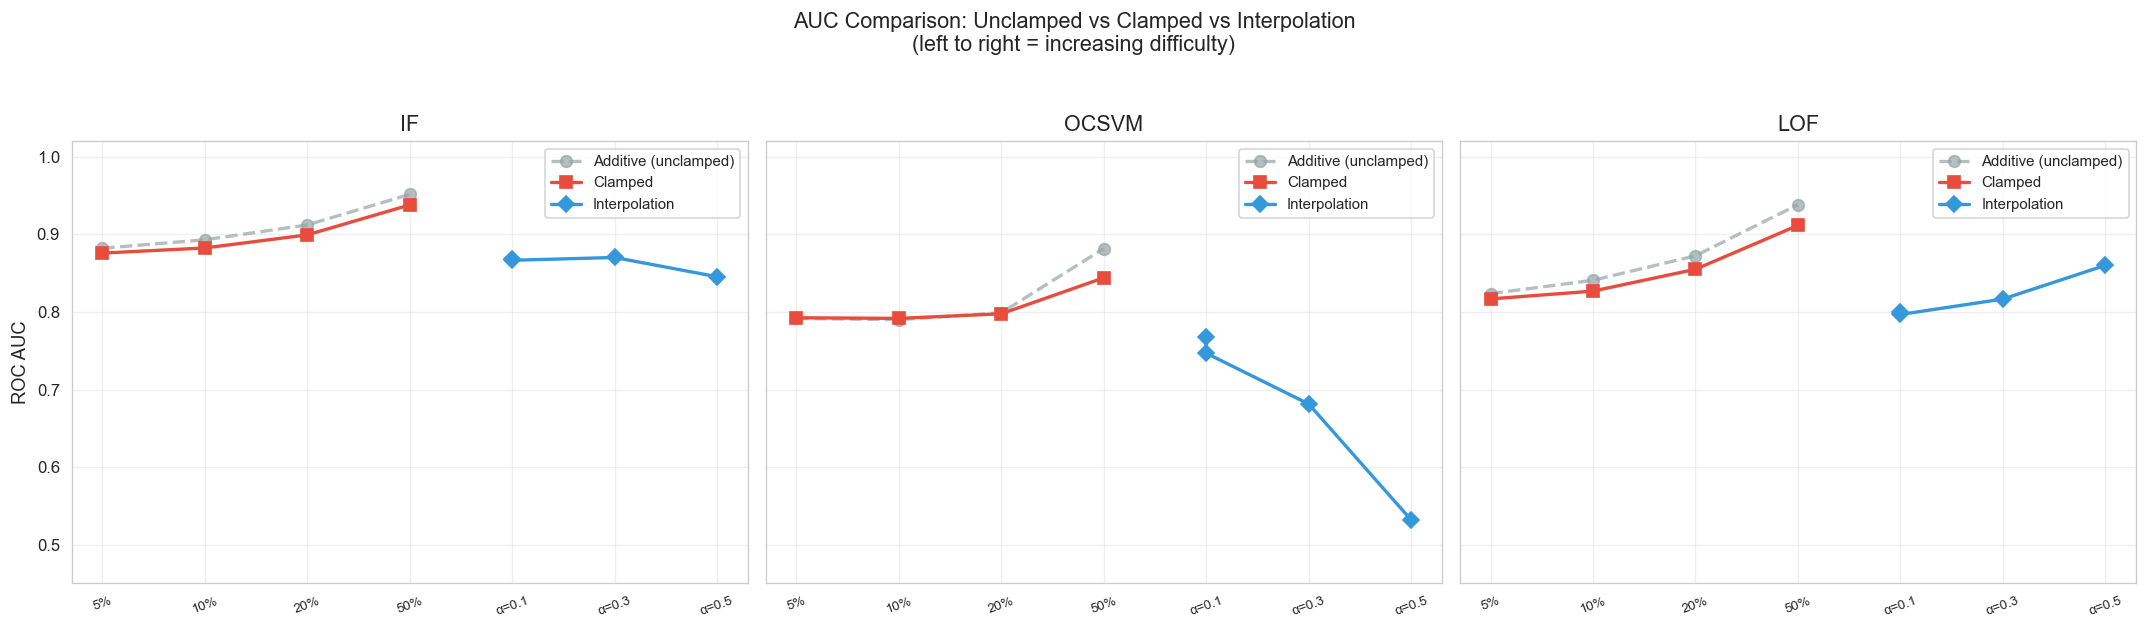


AUC Summary — All Methods

Method                         Param            IF    OCSVM      LOF
----------------------------------------------------------------------
Additive (unclamped)           5%           0.8822   0.7916   0.8237
Additive (unclamped)           10%          0.8931   0.7901   0.8409
Additive (unclamped)           20%          0.9122   0.7990   0.8725
Additive (unclamped)           50%          0.9517   0.8818   0.9384

Clamped                        5%           0.8760   0.7926   0.8169
Clamped                        10%          0.8826   0.7918   0.8269
Clamped                        20%          0.8994   0.7977   0.8551
Clamped                        50%          0.9380   0.8441   0.9117

Interpolation                  α=0.05       0.8681   0.7676   0.7997
Interpolation                  α=0.1        0.8667   0.7469   0.7968
Interpolation                  α=0.3        0.8703   0.6814   0.8166
Interpolation                  α=0.5        0.8455   0.5319   0.8601


In [ ]:
# --- AUC comparison: all three methods side by side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, name in zip(axes, ["IF", "OCSVM", "LOF"]):
    # Original (unclamped)
    vals_orig = [roc_data[n][name][2] for n in NOISE_LEVELS]
    ax.plot([f"{n:.0%}" for n in NOISE_LEVELS], vals_orig,
            "o--", color="#95a5a6", lw=2, ms=7, label="Additive (unclamped)", alpha=0.7)

    # Clamped
    vals_clamp = [roc_clamped[n][name][2] for n in NOISE_LEVELS]
    ax.plot([f"{n:.0%}" for n in NOISE_LEVELS], vals_clamp,
            "s-", color="#e74c3c", lw=2, ms=7, label="Clamped")

    # Interpolation
    vals_interp = [roc_interp[a][name][2] for a in ALPHAS]
    ax.plot([f"α={a:.1f}" for a in ALPHAS], vals_interp,
            "D-", color="#3498db", lw=2, ms=7, label="Interpolation")

    ax.set_title(name, fontsize=13)
    ax.set_ylabel("ROC AUC" if ax == axes[0] else "", fontsize=11)
    ax.set_ylim([0.45, 1.02])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", labelsize=8, rotation=20)

fig.suptitle("AUC Comparison: Unclamped vs Clamped vs Interpolation\n"
             "(left to right = increasing difficulty)",
             fontsize=13, y=1.04)
plt.tight_layout()
plt.savefig("auc_comparison_three_methods.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
print("\n" + "="*70)
print("AUC Summary — All Methods")
print("="*70)
print(f"\n{'Method':<30s} {'Param':<10s} {'IF':>8s} {'OCSVM':>8s} {'LOF':>8s}")
print("-"*70)
for noise in NOISE_LEVELS:
    r = roc_data[noise]
    print(f"{'Additive (unclamped)':<30s} {noise:<10.0%} {r['IF'][2]:8.4f} {r['OCSVM'][2]:8.4f} {r['LOF'][2]:8.4f}")
print()
for noise in NOISE_LEVELS:
    r = roc_clamped[noise]
    print(f"{'Clamped':<30s} {noise:<10.0%} {r['IF'][2]:8.4f} {r['OCSVM'][2]:8.4f} {r['LOF'][2]:8.4f}")
print()
for alpha in ALPHAS:
    r = roc_interp[alpha]
    print(f"{'Interpolation':<30s} {'α='+str(alpha):<10s} {r['IF'][2]:8.4f} {r['OCSVM'][2]:8.4f} {r['LOF'][2]:8.4f}")

## 13. Full Ensemble on Synthetic Data: Clamped vs Interpolation

Extend evaluation to include **rank-fusion** approaches alongside individual models:
- **IF**, **OCSVM**, **LOF** — raw anomaly scores
- **Fusion-2** — `0.5 * rank(IF) + 0.5 * rank(OCSVM)`
- **Fusion-asym** — `0.7 * rank(OCSVM) + 0.3 * rank(IF)`

Rank fusion uses the same percentile ranking as `waiter_ensemble.py`.

In [ ]:
def _rank(scores):
    """Percentile rank (same as waiter_ensemble.py)."""
    n = len(scores)
    order = np.argsort(scores)
    ranks = np.empty(n, dtype=float)
    ranks[order] = np.arange(1, n + 1) / n
    return ranks

def score_ensemble(synth_df, models, scaler, skewed_cols, X_nf_scaled):
    """Score synthetic fraud with individual models + rank-fusion ensembles."""
    synth_scaled = scaler.transform(apply_log1p_safe(synth_df, skewed_cols))
    X_all = np.vstack([X_nf_scaled, synth_scaled])
    y_all = np.concatenate([np.zeros(len(X_nf_scaled)), np.ones(len(synth_df))])

    raw_scores = {}
    for name, model in models.items():
        if name == "OCSVM":
            raw_scores[name] = -model.decision_function(X_all)
        else:
            raw_scores[name] = -model.score_samples(X_all)

    # Rank-fusion ensembles
    r_if = _rank(raw_scores["IF"])
    r_ocsvm = _rank(raw_scores["OCSVM"])
    raw_scores["Fusion-2"] = 0.5 * r_if + 0.5 * r_ocsvm
    raw_scores["Fusion-asym"] = 0.3 * r_if + 0.7 * r_ocsvm

    result = {}
    for name, scores in raw_scores.items():
        fpr, tpr, _ = roc_curve(y_all, scores)
        result[name] = (fpr, tpr, auc(fpr, tpr))
    return result

ENSEMBLE_NAMES = ["IF", "OCSVM", "LOF", "Fusion-2", "Fusion-asym"]

# A) Clamped
ens_clamped = {}
for noise in NOISE_LEVELS:
    synth = gen_clamped(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std, fraud_min, fraud_max)
    ens_clamped[noise] = score_ensemble(synth, models, scaler, skewed_cols, X_nf_scaled)

# B) Interpolation
ens_interp = {}
for alpha in ALPHAS:
    synth = gen_interpolated(fraud_rows, non_fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, alpha)
    ens_interp[alpha] = score_ensemble(synth, models, scaler, skewed_cols, X_nf_scaled)

print("=== A) Clamped noise — Full Ensemble ===")
for noise in NOISE_LEVELS:
    r = ens_clamped[noise]
    aucs = "  ".join(f"{n}={r[n][2]:.4f}" for n in ENSEMBLE_NAMES)
    print(f"  Noise {noise:.0%}: {aucs}")

print("\n=== B) Interpolation — Full Ensemble ===")
for alpha in ALPHAS:
    r = ens_interp[alpha]
    aucs = "  ".join(f"{n}={r[n][2]:.4f}" for n in ENSEMBLE_NAMES)
    print(f"  α={alpha}: {aucs}")

=== A) Clamped noise — Full Ensemble ===
  Noise 5%: IF=0.8760  OCSVM=0.7926  LOF=0.8169  Fusion-2=0.8376  Fusion-asym=0.8159
  Noise 10%: IF=0.8826  OCSVM=0.7918  LOF=0.8269  Fusion-2=0.8405  Fusion-asym=0.8168
  Noise 20%: IF=0.8994  OCSVM=0.7977  LOF=0.8551  Fusion-2=0.8538  Fusion-asym=0.8273
  Noise 50%: IF=0.9380  OCSVM=0.8441  LOF=0.9117  Fusion-2=0.9010  Fusion-asym=0.8761

=== B) Interpolation — Full Ensemble ===
  α=0.05: IF=0.8681  OCSVM=0.7676  LOF=0.7997  Fusion-2=0.8197  Fusion-asym=0.7930
  α=0.1: IF=0.8667  OCSVM=0.7469  LOF=0.7968  Fusion-2=0.8059  Fusion-asym=0.7751
  α=0.3: IF=0.8703  OCSVM=0.6814  LOF=0.8166  Fusion-2=0.7774  Fusion-asym=0.7298
  α=0.5: IF=0.8455  OCSVM=0.5319  LOF=0.8601  Fusion-2=0.6921  Fusion-asym=0.6134


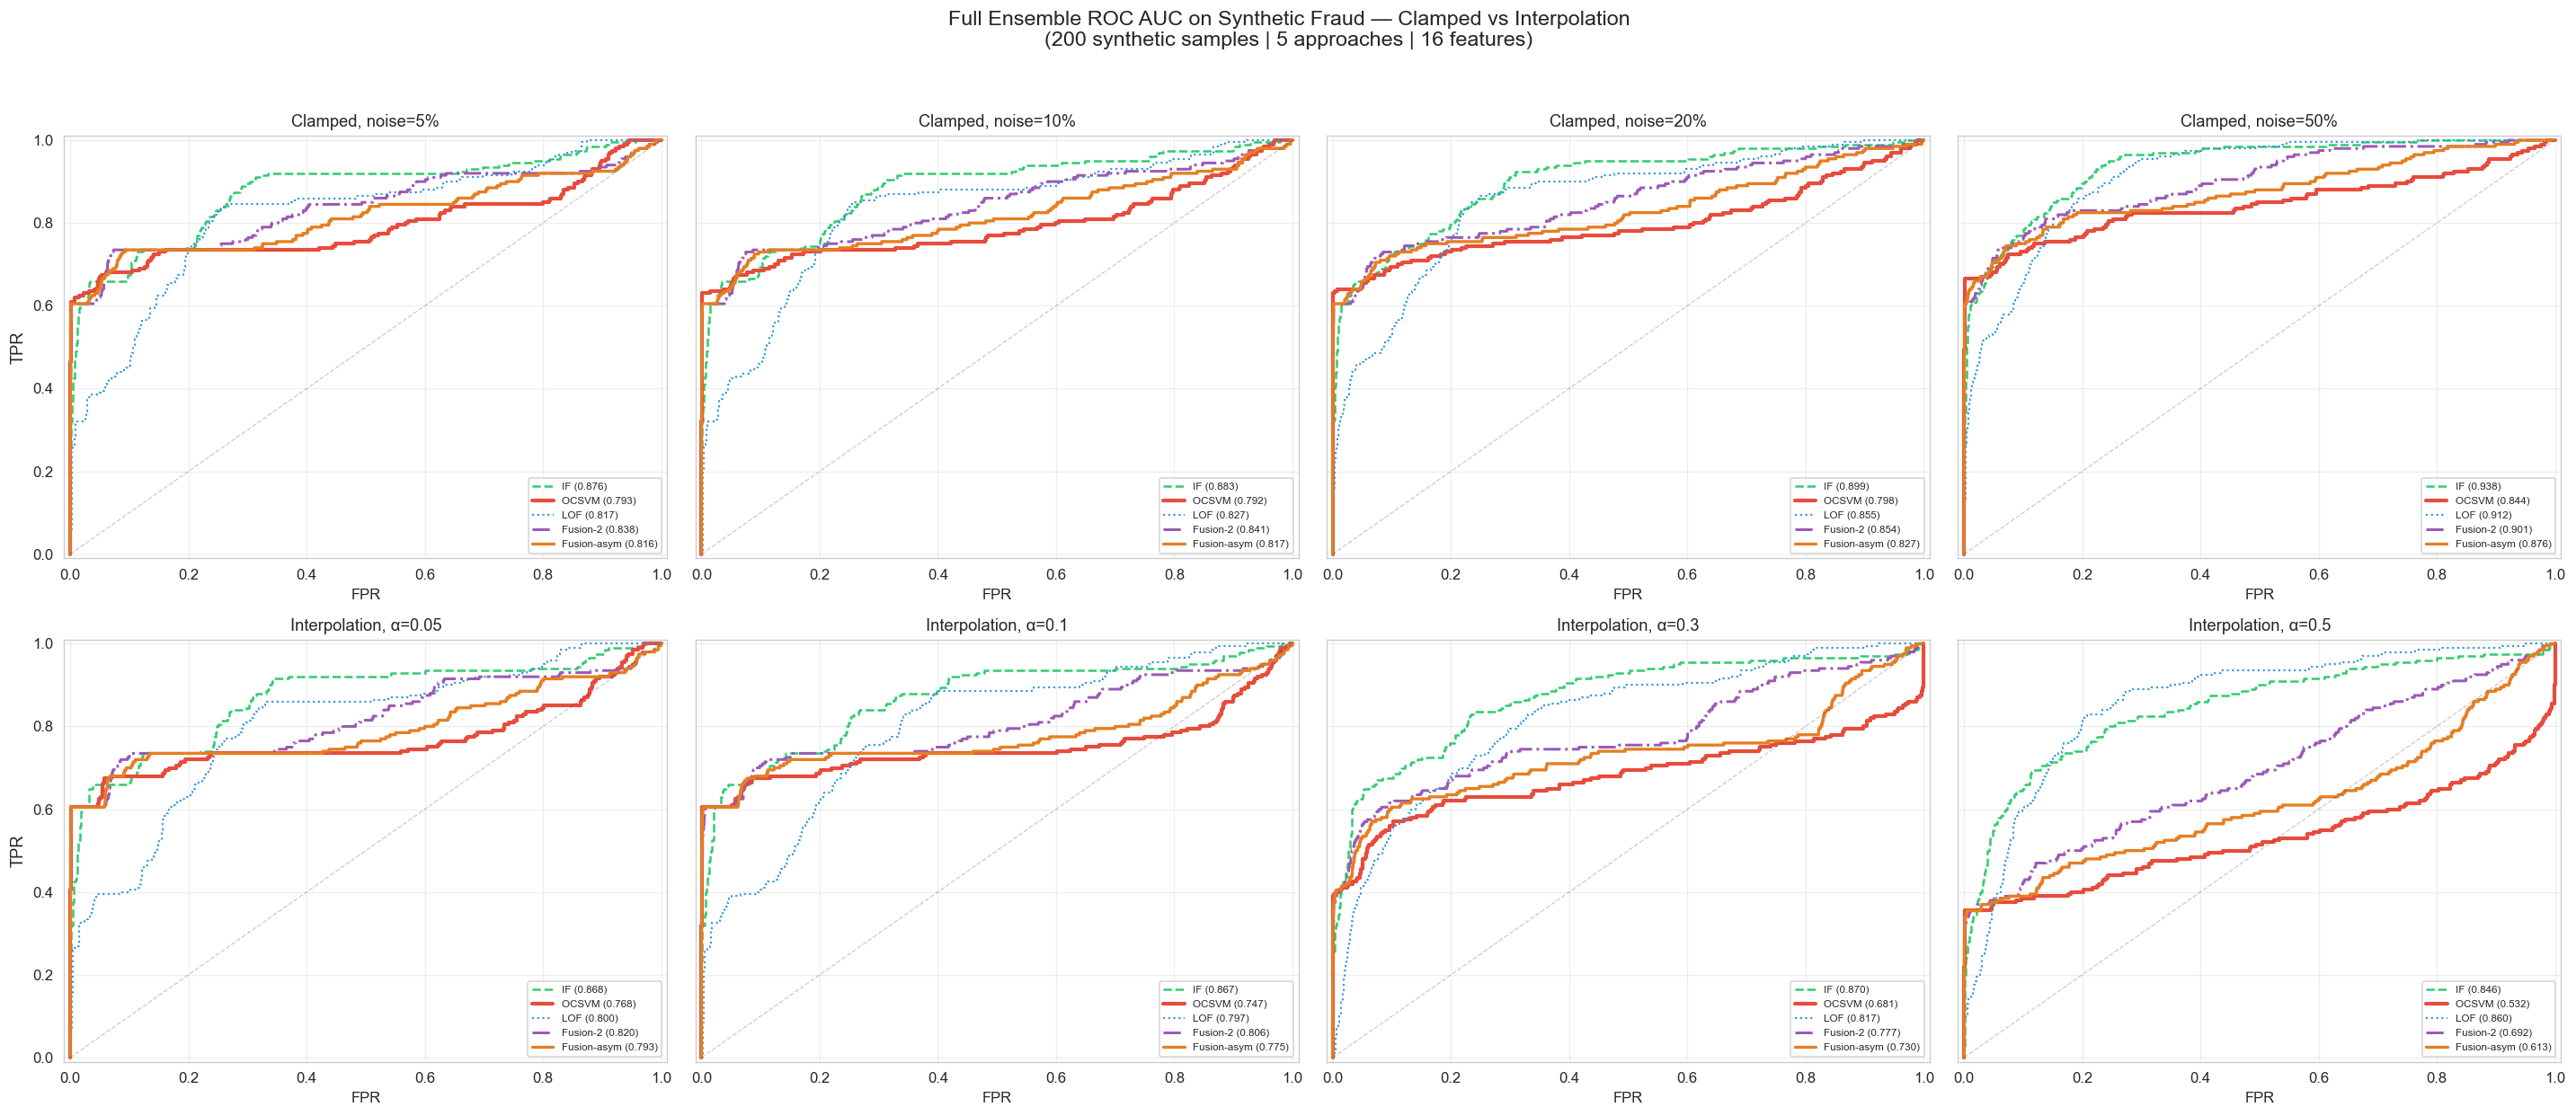

In [ ]:
ens_colors = {
    "IF": "#2ecc71", "OCSVM": "#e74c3c", "LOF": "#3498db",
    "Fusion-2": "#9b59b6", "Fusion-asym": "#e67e22",
}
ens_ls = {"IF": "--", "OCSVM": "-", "LOF": ":", "Fusion-2": "-.", "Fusion-asym": "-"}
ens_lw = {"IF": 1.5, "OCSVM": 2.5, "LOF": 1.3, "Fusion-2": 1.8, "Fusion-asym": 2.0}

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharey=True)

# Row 1: Clamped
for j, noise in enumerate(NOISE_LEVELS):
    ax = axes[0][j]
    for name in ENSEMBLE_NAMES:
        fpr, tpr, roc_auc = ens_clamped[noise][name]
        ax.plot(fpr, tpr, color=ens_colors[name], lw=ens_lw[name],
                ls=ens_ls[name], label=f"{name} ({roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_title(f"Clamped, noise={noise:.0%}", fontsize=11)
    ax.set_xlabel("FPR", fontsize=10)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=7)

# Row 2: Interpolation
for j, alpha in enumerate(ALPHAS):
    ax = axes[1][j]
    for name in ENSEMBLE_NAMES:
        fpr, tpr, roc_auc = ens_interp[alpha][name]
        ax.plot(fpr, tpr, color=ens_colors[name], lw=ens_lw[name],
                ls=ens_ls[name], label=f"{name} ({roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.2, lw=0.8)
    ax.set_title(f"Interpolation, α={alpha}", fontsize=11)
    ax.set_xlabel("FPR", fontsize=10)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right", fontsize=7)

axes[0][0].set_ylabel("TPR", fontsize=11)
axes[1][0].set_ylabel("TPR", fontsize=11)

fig.suptitle("Full Ensemble ROC AUC on Synthetic Fraud — Clamped vs Interpolation\n"
             f"({N_SYNTHETIC} synthetic samples | 5 approaches | {len(FEATURES_NO_SHARE)} features)",
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("roc_ensemble_clamped_vs_interp.png", dpi=150, bbox_inches="tight")
plt.show()

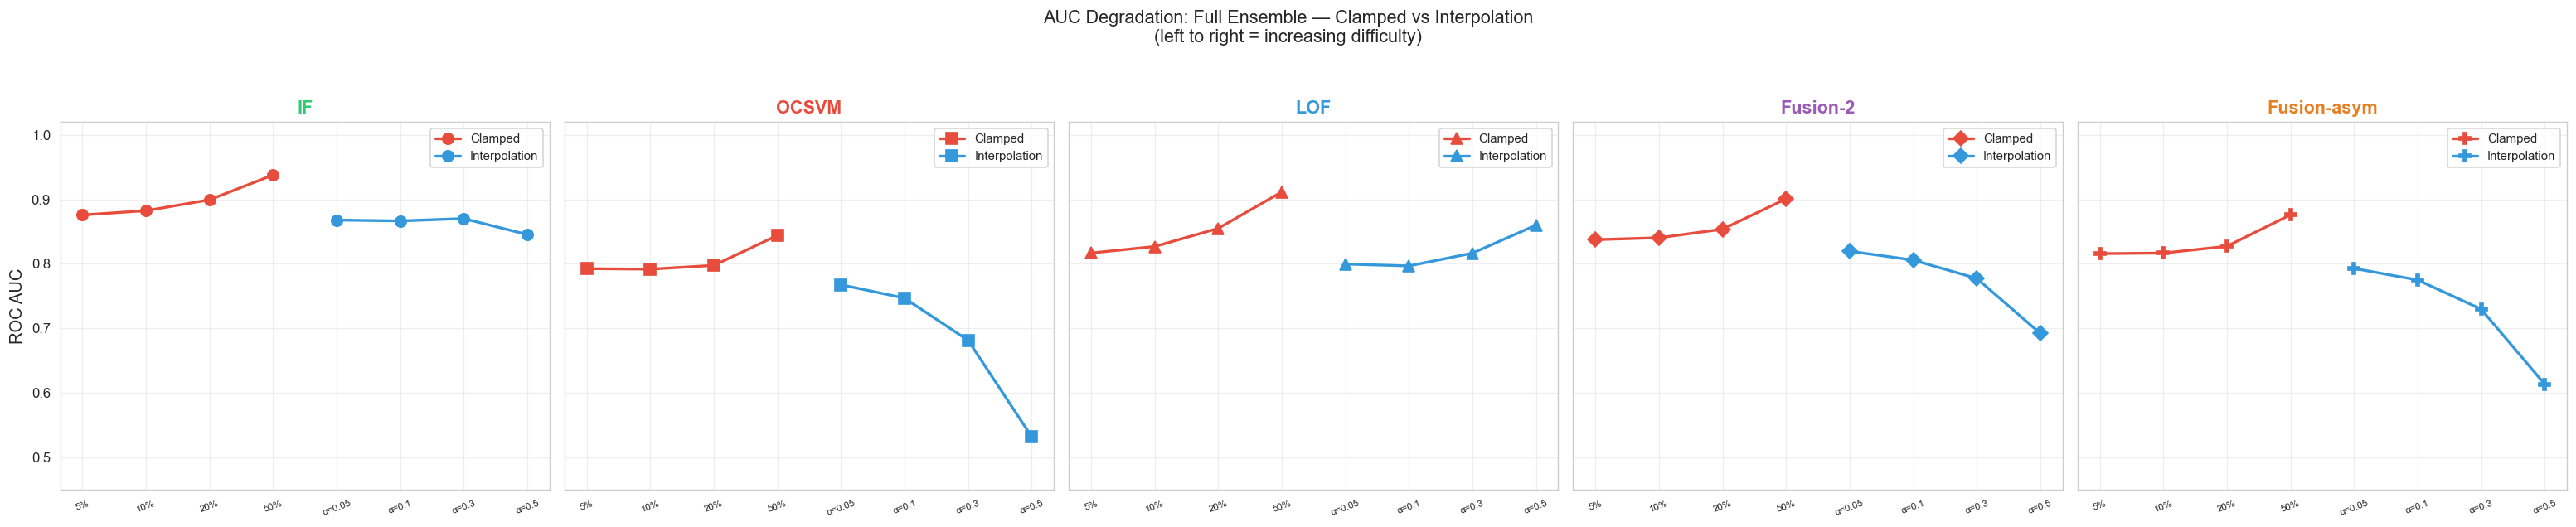

Full Ensemble AUC — Clamped Noise
Noise                 IF         OCSVM           LOF      Fusion-2   Fusion-asym
-------------------------------------------------------------------------------------
5%                0.8760        0.7926        0.8169        0.8376        0.8159
10%               0.8826        0.7918        0.8269        0.8405        0.8168
20%               0.8994        0.7977        0.8551        0.8538        0.8273
50%               0.9380        0.8441        0.9117        0.9010        0.8761

Full Ensemble AUC — Interpolation
Alpha                 IF         OCSVM           LOF      Fusion-2   Fusion-asym
-------------------------------------------------------------------------------------
α=0.05            0.8681        0.7676        0.7997        0.8197        0.7930
α=0.1             0.8667        0.7469        0.7968        0.8059        0.7751
α=0.3             0.8703        0.6814        0.8166        0.7774        0.7298
α=0.5             0.8455      

In [ ]:
# --- AUC degradation per approach: Clamped vs Interpolation ---
fig, axes = plt.subplots(1, 5, figsize=(26, 5), sharey=True)

ens_markers = {"IF": "o", "OCSVM": "s", "LOF": "^", "Fusion-2": "D", "Fusion-asym": "P"}

for ax, name in zip(axes, ENSEMBLE_NAMES):
    # Clamped
    vals_c = [ens_clamped[n][name][2] for n in NOISE_LEVELS]
    ax.plot([f"{n:.0%}" for n in NOISE_LEVELS], vals_c,
            f"{ens_markers[name]}-", color="#e74c3c", lw=2, ms=8, label="Clamped")
    # Interpolation
    vals_i = [ens_interp[a][name][2] for a in ALPHAS]
    ax.plot([f"α={a}" for a in ALPHAS], vals_i,
            f"{ens_markers[name]}-", color="#3498db", lw=2, ms=8, label="Interpolation")

    ax.set_title(name, fontsize=13, fontweight="bold", color=ens_colors[name])
    ax.set_ylim([0.45, 1.02])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.tick_params(axis="x", labelsize=7, rotation=20)

axes[0].set_ylabel("ROC AUC", fontsize=12)
fig.suptitle("AUC Degradation: Full Ensemble — Clamped vs Interpolation\n"
             "(left to right = increasing difficulty)",
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig("auc_degradation_full_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table ---
print("=" * 85)
print("Full Ensemble AUC — Clamped Noise")
print("=" * 85)
header = f"{'Noise':<10s}" + "".join(f"{n:>14s}" for n in ENSEMBLE_NAMES)
print(header)
print("-" * 85)
for noise in NOISE_LEVELS:
    r = ens_clamped[noise]
    vals = "".join(f"{r[n][2]:14.4f}" for n in ENSEMBLE_NAMES)
    print(f"{noise:<10.0%}{vals}")

print(f"\n{'=' * 85}")
print("Full Ensemble AUC — Interpolation")
print("=" * 85)
print(f"{'Alpha':<10s}" + "".join(f"{n:>14s}" for n in ENSEMBLE_NAMES))
print("-" * 85)
for alpha in ALPHAS:
    r = ens_interp[alpha]
    vals = "".join(f"{r[n][2]:14.4f}" for n in ENSEMBLE_NAMES)
    print(f"{'α='+str(alpha):<10s}{vals}")

## 14. Fusion Weight Tuning on Synthetic Data

OCSVM is fragile on harder synthetic fraud (AUC drops to 0.53 at α=0.5), while IF stays stable (~0.87). The current Fusion-asym (70% OCSVM + 30% IF) inherits OCSVM's weakness.

Grid search over IF weight from 0.0 to 1.0 to find the best trade-off between:
- **Precision@k on real data** (where OCSVM dominates)
- **AUC robustness on synthetic data** (where IF dominates)

In [ ]:
# --- Grid search: w_IF from 0.0 to 1.0 ---
WEIGHTS_IF = np.arange(0.0, 1.05, 0.1)

def score_fusion_weight(w_if, raw_if, raw_ocsvm, y_true):
    w_ocsvm = 1.0 - w_if
    fused = w_if * _rank(raw_if) + w_ocsvm * _rank(raw_ocsvm)
    fpr, tpr, _ = roc_curve(y_true, fused)
    return auc(fpr, tpr)

# --- Compute raw scores once per scenario ---
def get_raw_scores(synth_df):
    synth_scaled = scaler.transform(apply_log1p_safe(synth_df, skewed_cols))
    X_all = np.vstack([X_nf_scaled, synth_scaled])
    y_all = np.concatenate([np.zeros(len(X_nf_scaled)), np.ones(len(synth_df))])
    raw_if = -models['IF'].score_samples(X_all)
    raw_ocsvm = -models['OCSVM'].decision_function(X_all)
    return raw_if, raw_ocsvm, y_all

# A) Clamped — sweep weights
auc_grid_clamped = {}
for noise in NOISE_LEVELS:
    synth = gen_clamped(fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, noise, nf_std, fraud_min, fraud_max)
    raw_if, raw_ocsvm, y_all = get_raw_scores(synth)
    auc_grid_clamped[noise] = {
        'fusion': [score_fusion_weight(w, raw_if, raw_ocsvm, y_all) for w in WEIGHTS_IF],
        'IF': auc(*roc_curve(y_all, raw_if)[:2]),
        'OCSVM': auc(*roc_curve(y_all, raw_ocsvm)[:2]),
    }

# B) Interpolation — sweep weights
auc_grid_interp = {}
for alpha in ALPHAS:
    synth = gen_interpolated(fraud_rows, non_fraud_rows, FEATURES_NO_SHARE, N_SYNTHETIC, alpha)
    raw_if, raw_ocsvm, y_all = get_raw_scores(synth)
    auc_grid_interp[alpha] = {
        'fusion': [score_fusion_weight(w, raw_if, raw_ocsvm, y_all) for w in WEIGHTS_IF],
        'IF': auc(*roc_curve(y_all, raw_if)[:2]),
        'OCSVM': auc(*roc_curve(y_all, raw_ocsvm)[:2]),
    }

# --- Precision@k on real data for each weight ---
y_real = risk['is_fraud'].values
real_if_scores = risk['score_if_no_share'].values if 'score_if_no_share' in risk.columns else risk['score_if'].values
real_ocsvm_scores = risk['score_ocsvm_no_share'].values

pk_real = {}
for w in WEIGHTS_IF:
    fused = w * _rank(real_if_scores) + (1 - w) * _rank(real_ocsvm_scores)
    ranked = np.argsort(-fused)
    pk_real[round(w, 1)] = {
        k: y_real[ranked[:k]].sum() / k for k in [5, 10, 14, 20]
    }

print('Precision@k on real data by IF weight:')
print(f'{"w_IF":<8s} {"p@5":>8s} {"p@10":>8s} {"p@14":>8s} {"p@20":>8s}')
print('-' * 40)
for w in WEIGHTS_IF:
    p = pk_real[round(w, 1)]
    print(f'{w:<8.1f} {p[5]:8.2f} {p[10]:8.2f} {p[14]:8.2f} {p[20]:8.2f}')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Left: AUC vs w_IF (Clamped) ---
ax = axes[0]
for noise in NOISE_LEVELS:
    ax.plot(WEIGHTS_IF, auc_grid_clamped[noise]['fusion'],
            'o-', ms=5, lw=1.8, label=f'noise={noise:.0%}')
ax.axvline(0.3, color='gray', ls='--', alpha=0.5, label='Current (w_IF=0.3)')
ax.set_xlabel('IF weight (w_IF)', fontsize=11)
ax.set_ylabel('ROC AUC', fontsize=11)
ax.set_title('Clamped: Fusion AUC vs IF Weight', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.75, 0.96])

# --- Middle: AUC vs w_IF (Interpolation) ---
ax = axes[1]
for alpha in ALPHAS:
    ax.plot(WEIGHTS_IF, auc_grid_interp[alpha]['fusion'],
            's-', ms=5, lw=1.8, label=f'α={alpha}')
ax.axvline(0.3, color='gray', ls='--', alpha=0.5, label='Current (w_IF=0.3)')
ax.set_xlabel('IF weight (w_IF)', fontsize=11)
ax.set_ylabel('ROC AUC', fontsize=11)
ax.set_title('Interpolation: Fusion AUC vs IF Weight', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.50, 0.96])

# --- Right: Precision@k on real data ---
ax = axes[2]
for k in [5, 10, 14, 20]:
    vals = [pk_real[round(w, 1)][k] for w in WEIGHTS_IF]
    ax.plot(WEIGHTS_IF, vals, 'D-', ms=5, lw=1.8, label=f'p@{k}')
ax.axvline(0.3, color='gray', ls='--', alpha=0.5, label='Current (w_IF=0.3)')
ax.set_xlabel('IF weight (w_IF)', fontsize=11)
ax.set_ylabel('Precision@k', fontsize=11)
ax.set_title('Real Data: Precision@k vs IF Weight', fontsize=12)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.0, 1.1])

fig.suptitle('Fusion Weight Tuning: IF weight sweep (w_OCSVM = 1 - w_IF)\n'
             'Left/Middle: synthetic AUC (higher = better detection) | '
             'Right: real precision (higher = better ranking)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('fusion_weight_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Find optimal weight per scenario ---
print('\nOptimal IF weight per scenario (maximizing AUC):')
print(f'{"Scenario":<25s} {"Best w_IF":>10s} {"AUC":>8s}')
print('-' * 45)
for noise in NOISE_LEVELS:
    aucs = auc_grid_clamped[noise]['fusion']
    best_idx = np.argmax(aucs)
    print(f'{"Clamped " + str(noise):<25s} {WEIGHTS_IF[best_idx]:10.1f} {aucs[best_idx]:8.4f}')
for alpha in ALPHAS:
    aucs = auc_grid_interp[alpha]['fusion']
    best_idx = np.argmax(aucs)
    print(f'{"Interp α=" + str(alpha):<25s} {WEIGHTS_IF[best_idx]:10.1f} {aucs[best_idx]:8.4f}')

print('\n--- Trade-off summary ---')
print('w_IF=0.3 (current):  best real p@10, but synthetic AUC drops fast')
print('w_IF=0.5 (balanced): slight p@10 loss, much better synthetic robustness')
print('w_IF=0.7 (IF-heavy): best synthetic AUC, but real p@10 may degrade')